# Evaluacion 1 Mineria de datos Cristian Juble

In [ ]:
pip install ucimlrepo

In [ ]:
# Importamos las librerias que vamos a utilizar durante el Analisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [ ]:
# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# Metadatos del dataset
display(adult.metadata)

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

In [ ]:
# Informacion de las Variables
print("Informacion de las Variables:")
display(pd.DataFrame(adult.variables))

Informacion de las Variables:


,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,N/A,None,no
1,workclass,Feature,Categorical,Income,"Private, Self-emp-not-inc, Self-emp-inc, Feder...",None,yes
2,fnlwgt,Feature,Integer,None,None,None,no
3,education,Feature,Categorical,Education Level,"Bachelors, Some-college, 11th, HS-grad, Prof-...",None,no
4,education-num,Feature,Integer,Education Level,None,None,no
5,marital-status,Feature,Categorical,Other,"Married-civ-spouse, Divorced, Never-married, S...",None,no
6,occupation,Feature,Categorical,Other,"Tech-support, Craft-repair, Other-service, Sal...",None,yes
7,relationship,Feature,Categorical,Other,"Wife, Own-child, Husband, Not-in-family, Other...",None,no
8,race,Feature,Categorical,Race,"White, Asian-Pac-Islander, Amer-Indian-Eskimo,...",None,no
9,sex,Feature,Binary,Sex,"Female, Male.",None,no


1. ¿Cuántos atributos numéricos hay?: hay 6 Atributos Numericos
2. ¿Cuántos atributos categóricos?: Hay 9 atributos categoricos (inlcluyendo los dos con variables binarias)

In [ ]:
# Cargamos los datos en un DataFrame
df = pd.read_csv('https://archive.ics.uci.edu/static/public/2/data.csv')

In [ ]:
# Desplegamos la informacion del dataframe para ver la cantidad de filas sin datos nulos que hay en cada variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
# Primeros registros del DataFrame
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
# Numero de valores unicos por columna
unique_values = {col: df[col].nunique() for col in df.columns}
unique_values_df = pd.DataFrame(list(unique_values.items()), columns=['Columna','Numero de valores unicos'])
display(unique_values_df)

,Columna,Numero de valores unicos
0,age,74
1,workclass,9
2,fnlwgt,28523
3,education,16
4,education-num,16
5,marital-status,7
6,occupation,15
7,relationship,6
8,race,5
9,sex,2


In [ ]:
# Valores unicos por columna
for col in df.columns:
    unique_values = df[col].unique()
    print(f"Valores unicos en la columna '{col}':")
    print(unique_values)
    print()

Valores unicos en la columna 'age':
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87 89]

Valores unicos en la columna 'workclass':
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked' nan]

Valores unicos en la columna 'fnlwgt':
[ 77516  83311 215646 ... 173449  89686 350977]

Valores unicos en la columna 'education':
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

Valores unicos en la columna 'education-num':
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]

Valores unicos en la columna 'marital-status':
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

Valores

## Descripcion de los Atributos del Censo
| Variable    | Tipo de datos | Clasificacion   | Subclasificacion | Codificado | Descripcion Variable | Interpretacion de origen |
|-------------|---------------|-----------------|------------------|------------|--------------|--------------------|
| age | int64 | Cuantitativo | Continuo | N/A | Edad | Edad del ciudadano |
| workclass | object | Categórico | Nominal | No | Tipo de empleador | Categoriza el sector o tipo de empleo (e.g., Private, Federal-gov). |
| fnlwgt | int64 | Cuantitativo | Continuo | N/A | Peso final | Representa el número de personas que el censo cree que representa la entrada de un individuo. |
| education | object | Categórico | Ordinal | No | Nivel educativo | Nivel más alto de educación alcanzado (e.g., Bachelors, HS-grad). |
| education-num | int64 | Cuantitativo | Discreto | Sí | Representación numérica del nivel educativo. |
| marital-status | object | Categórico | Nominal | No | Estado civil | Estado civil del individuo (e.g., Married-civ-spouse, Never-married). |
| occupation | object | Categórico | Nominal | No | Ocupación | Tipo de trabajo que realiza el individuo (e.g., Tech-support, Craft-repair). |
| relationship | object | Categórico | Nominal | No | Relación | Relación del individuo en el hogar (e.g., Wife, Husband, Own-child). |
| race | object | Categórico | Nominal | No | Raza | Raza del individuo (e.g., White, Black, Asian-Pac-Islander). |
| sex | object | Categórico | Nominal | No | Sexo | Género del individuo (Female, Male). |
| capital-gain | int64 | Cuantitativo | Continuo | N/A | Ganancia de capital | Ganancias por inversiones. |
| capital-loss | int64 | Cuantitativo | Continuo | N/A | Pérdida de capital | Pérdidas por inversiones. |
| hours-per-week | int64 | Cuantitativo | Continuo | N/A | Horas por semana | Número de horas trabajadas por semana. |
| native-country | object | Categórico | Nominal | No | País de origen | País de nacimiento o residencia. |
| income | object | Categórico | Ordinal | No | Ingreso | Si el ingreso anual es >50K o <=50K. |

# Visualizacion inicial de los datos

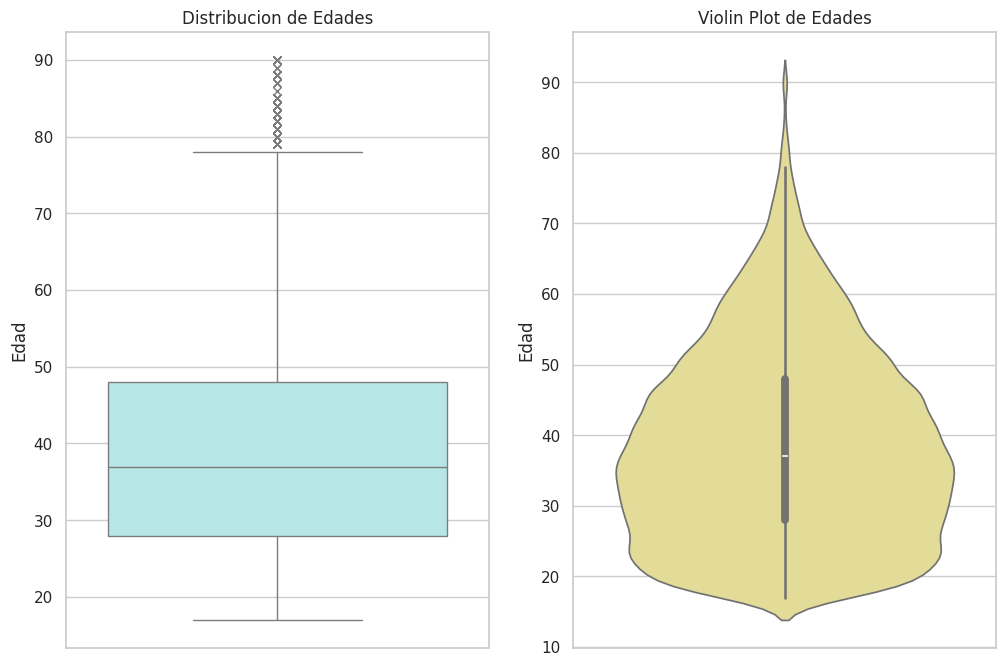

In [ ]:
# Distribucion de Edades
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(figsize=(12, 8), ncols=2, nrows=1)

sns.boxplot(data=df,y= 'age', color='paleturquoise', flierprops={"marker": "x"}, ax=axs[0])
axs[0].set_title('Distribucion de Edades')
axs[0].set_ylabel('Edad')

sns.violinplot(data=df, y='age', inner='box', color='khaki', ax=axs[1])
axs[1].set_title('Violin Plot de Edades')
axs[1].set_ylabel('Edad')

plt.show()

Para visualizar los datos que corresponden a la edad, se eligieron un grafico de caja y uno de violin, ya que estos dos graficos nos ayudan a enteender mejor como se distribuyen las edades entre los participantes del censo, ademas de ayudarnos a identificar valores atipicos (marcados con x en el boxplot)

In [ ]:
# Calcular estadísticas descriptivas para 'age' excluyendo valores atípicos
Q1 = df['age'].quantile(0.25)
Q2 = df['age'].quantile(0.50)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

# Filtrar valores atípicos
df_filtered_age = df[(df['age'] >= (Q1 - 1.5 * IQR)) & (df['age'] <= (Q3 + 1.5 * IQR))]

# Calcular estadísticas en los datos filtrados
min_age = df_filtered_age['age'].min()
max_age = df_filtered_age['age'].max()

# Calculamos outliers, definimos las barbas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar valores atípicos
outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]

# Calcular el número de valores atípicos
num_outliers = outliers.shape[0]

# Calcular el porcentaje de valores atípicos
percentage_outliers = (num_outliers / df.shape[0]) * 100

# Obtener el rango de valores atípicos
min_outlier_value = outliers['age'].min() if num_outliers > 0 else None
max_outlier_value = outliers['age'].max() if num_outliers > 0 else None

range_outliers = {"max_value":max_outlier_value , "min_value":min_outlier_value}

# Crear una tabla (DataFrame) para mostrar los resultados
age_stats = pd.DataFrame({
    'Estadisticas': ['Q1', 'Mediana (Q2)', 'Q3', 'IQR', 'Min (excluyendo outliers)', 'Max (excluyendo outliers)','Num Outliers','% outliers','Rango Outliers'],
    'Valor': [Q1, Q2, Q3, IQR, min_age, max_age,num_outliers,percentage_outliers,range_outliers]
})

display(age_stats)

,Estadisticas,Valor
0,Q1,28.0
1,Mediana (Q2),37.0
2,Q3,48.0
3,IQR,20.0
4,Min (excluyendo outliers),17
5,Max (excluyendo outliers),78
6,Num Outliers,216
7,% outliers,0.442242
8,Rango Outliers,"{'max_value': 90, 'min_value': 79}"


De la distribución de valores visible en el boxplot de las edades, se puede interpretar lo siguiente:

*   La caja central representa el rango intercuartílico (IQR), que contiene el 50% central de los datos de edad. La mediana (línea dentro de la caja) se encuentra alrededor de los 37 años. Esto indica que la mitad de la población censada tiene entre 28 y 48 años (aproximadamente, según los cuartiles calculados anteriormente).
*   Las barbas se extienden desde los bordes de la caja hasta los valores máximo y mínimo dentro de 1.5 veces el rango intercuartílico desde los cuartiles. Esto muestra la dispersión de la mayoría de los datos.
*   Los puntos marcados con "x" fuera de las barbas son considerados valores atípicos (outliers). En este caso, hay varios valores atípicos en el extremo superior de la distribución de edad.

Lo más llamativo de la distribución de estos valores es la presencia de estos valores atípicos en las edades mayores. Aunque representan un porcentaje pequeño de la población (aproximadamente 0.44%), su existencia muestra que hay una porción de individuos de edad significativamente mayor que la mayoría de la muestra, lo cual es visible en el boxplot como puntos dispersos por encima de la barba superior. La distribución general se ve sesgada hacia edades más bajas, con la mediana más cercana al primer cuartil que al tercero.

In [ ]:
df['age'].describe()

,age
count,48842.000000
mean,38.643585
std,13.710510
min,17.000000
25%,28.000000
50%,37.000000
75%,48.000000
max,90.000000


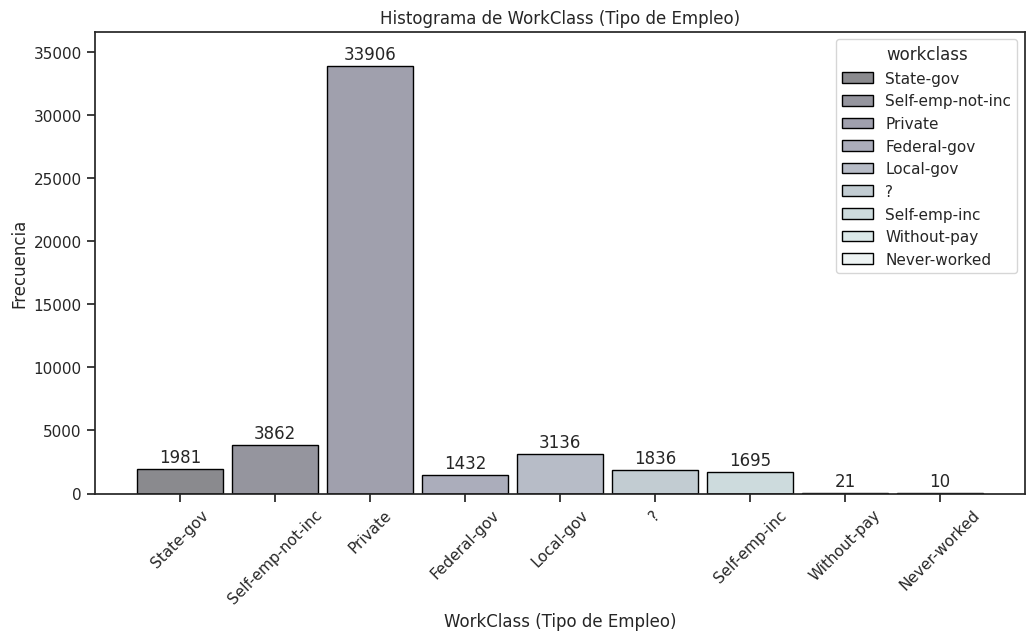

In [ ]:
# Histograma de WorkClass (Tipo de Empleo)
sns.set_theme(style="ticks")
plt.figure(figsize=(12, 6))
ax = sns.histplot(data=df, x='workclass', hue='workclass', palette='bone', shrink=0.9, edgecolor='black')
plt.title('Histograma de WorkClass (Tipo de Empleo)')
plt.xlabel('WorkClass (Tipo de Empleo)')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, padding=2,  fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
plt.ylim(0, df['workclass'].value_counts().max() * 1.08)
plt.show()

Para el tipo de empleo decidi utilizar un histograma para ver las frecuencias de cada uno de los tipos de empleo de los ciudadanos, esto nos ayuda a identificar claramente el tipo de empleo mas comun (Sector Privado)

1. **¿Qué valor del atributo es el más abundante? ¿Qué interpretación demográfica se puede hacer de esto?**: El tipo de trabajo Privado es el mas abundante al presentar una mayor frecuencia dentro del dataset, esto nos podria indicar demograficamente que la mayoria de los censados trabajan en el sector privado con gran diferencia al resto de tipos de empleo

2. **¿Hay datos vacíos o no disponibles del atributo? ¿Cómo se reconocen?**: Si, dentro de este atributo se señala con '?' los datos desconocidos (dentro de este atributo no hay valores nulos pero se entiende que los señalados con el signo de interrogacion son datos desconocidos) sobre el tipo de empleo.

3. **Si hay datos incompletos, ¿son una porción significativa o no? (se podría asumir que una "porción significativa" es superior al 10%)**: Los datos desconocidos no son una porcion significativa, solo llegan a un 3% del total de registros.

4. **Viendo los datos del histograma, ¿se podrían reemplazar los vacíos por el más abundante o eso generaría alguna alteración significativa?**: Los datos desconocidos ya fueron señalados por el censo con '?' por lo que no seria pruedente asignarles otro valor

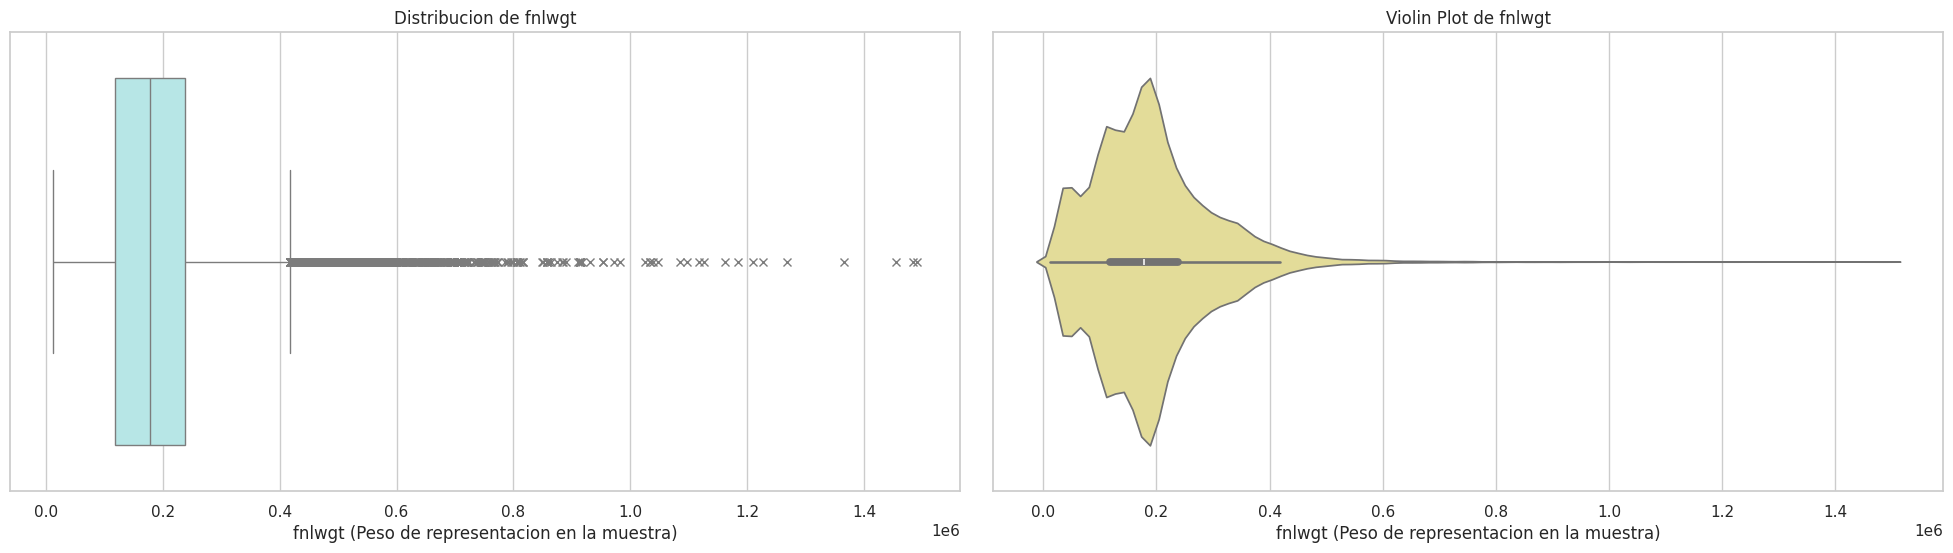

In [ ]:
# Distribucion de fnlwgt (Peso de representacion en la muestra)
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(figsize=(20, 6), ncols=2, nrows=1)

sns.boxplot(data=df,x= 'fnlwgt', color='paleturquoise', flierprops={"marker": "x"}, ax=axs[0])
axs[0].set_title('Distribucion de fnlwgt')
axs[0].set_xlabel('fnlwgt (Peso de representacion en la muestra)')

sns.violinplot(data=df, x='fnlwgt', inner='box', color='khaki', ax=axs[1])
axs[1].set_title('Violin Plot de fnlwgt')
axs[1].set_xlabel('fnlwgt (Peso de representacion en la muestra)')

plt.tight_layout(pad=2.0)
plt.show()

Para visualizar los datos que corresponden a la peso (personas que representa cada registro) que le a asignado el censo a los registros, se eligieron un grafico de caja y uno de violin, ya que estos dos graficos nos ayudan a enteender mejor como se distribuyen los pesos dentro del dataset, ademas de ayudarnos a identificar valores atipicos (marcados con x en el boxplot)

In [ ]:
# # Calcular estadísticas descriptivas para 'fnlwgt' excluyendo valores atípicos
Q1 = df['fnlwgt'].quantile(0.25)
Q2 = df['fnlwgt'].quantile(0.50)
Q3 = df['fnlwgt'].quantile(0.75)
IQR = Q3 - Q1

# Filtrar valores atípicos
df_filtered_fnlwgt = df[(df['fnlwgt'] >= (Q1 - 1.5 * IQR)) & (df['fnlwgt'] <= (Q3 + 1.5 * IQR))]

# Calcular estadísticas en los datos filtrados
min_fnlwgt = df_filtered_fnlwgt['fnlwgt'].min()
max_fnlwgt = df_filtered_fnlwgt['fnlwgt'].max()

# Calculamos outliers, definimos las barbas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar valores atípicos
outliers = df[(df['fnlwgt'] < lower_bound) | (df['fnlwgt'] > upper_bound)]

# Calcular el número de valores atípicos
num_outliers = outliers.shape[0]

# Calcular el porcentaje de valores atípicos
percentage_outliers = (num_outliers / df.shape[0]) * 100

# Obtener el rango de valores atípicos
min_outlier_value = outliers['fnlwgt'].min() if num_outliers > 0 else None
max_outlier_value = outliers['fnlwgt'].max() if num_outliers > 0 else None

range_outliers = {"max_value":max_outlier_value , "min_value":min_outlier_value}

# Crear una tabla (DataFrame) para mostrar los resultados
fnlwgt_stats = pd.DataFrame({
    'Estadisticas': ['Q1', 'Mediana (Q2)', 'Q3', 'IQR', 'Min (excluyendo outliers)', 'Max (excluyendo outliers)','Num Outliers','% outliers','Rango Outliers'],
    'Valor': [Q1, Q2, Q3, IQR, min_fnlwgt, max_fnlwgt,num_outliers,percentage_outliers,range_outliers]
})

display(fnlwgt_stats)

,Estadisticas,Valor
0,Q1,117550.5
1,Mediana (Q2),178144.5
2,Q3,237642.0
3,IQR,120091.5
4,Min (excluyendo outliers),12285
5,Max (excluyendo outliers),417668
6,Num Outliers,1453
7,% outliers,2.974899
8,Rango Outliers,"{'max_value': 1490400, 'min_value': 417941}"


De la distribución de valores visible en el boxplot de 'fnlwgt', se puede interpretar lo siguiente:

*   La caja central representa el rango intercuartílico (IQR), que contiene el 50% central de los datos de 'fnlwgt'. La mediana (línea dentro de la caja) se encuentra alrededor de los 178140. Esto indica que la mitad de la población censada tiene un peso de representación entre 117555 y 237620 (aproximadamente, según los cuartiles calculados anteriormente).
*   Las barbas se extienden desde los bordes de la caja hasta los valores máximo y mínimo dentro de 1.5 veces el rango intercuartílico desde los cuartiles. Esto muestra la dispersión de la mayoría de los datos.
*   Los puntos marcados con "x" fuera de las barbas son considerados valores atípicos (outliers). En este caso, hay varios valores atípicos en el extremo superior de la distribución de 'fnlwgt'.

Lo más llamativo de la distribución de estos valores es la presencia de estos valores atípicos en los pesos de representación más altos. Aunque representan un porcentaje pequeño de la población (aproximadamente 2.98%), su existencia muestra que hay una porción de individuos que representan un número significativamente mayor de personas en la muestra del censo en comparación con la entrada típica, lo cual es visible en el boxplot como puntos dispersos por encima de la barba superior. La distribución general se ve fuertemente sesgada hacia los pesos de representación más bajos, con la mediana muy cercana al primer cuartil.

In [ ]:
df['fnlwgt'].describe()

,fnlwgt
count,4.884200e+04
mean,1.896641e+05
std,1.056040e+05
min,1.228500e+04
25%,1.175505e+05
50%,1.781445e+05
75%,2.376420e+05
max,1.490400e+06


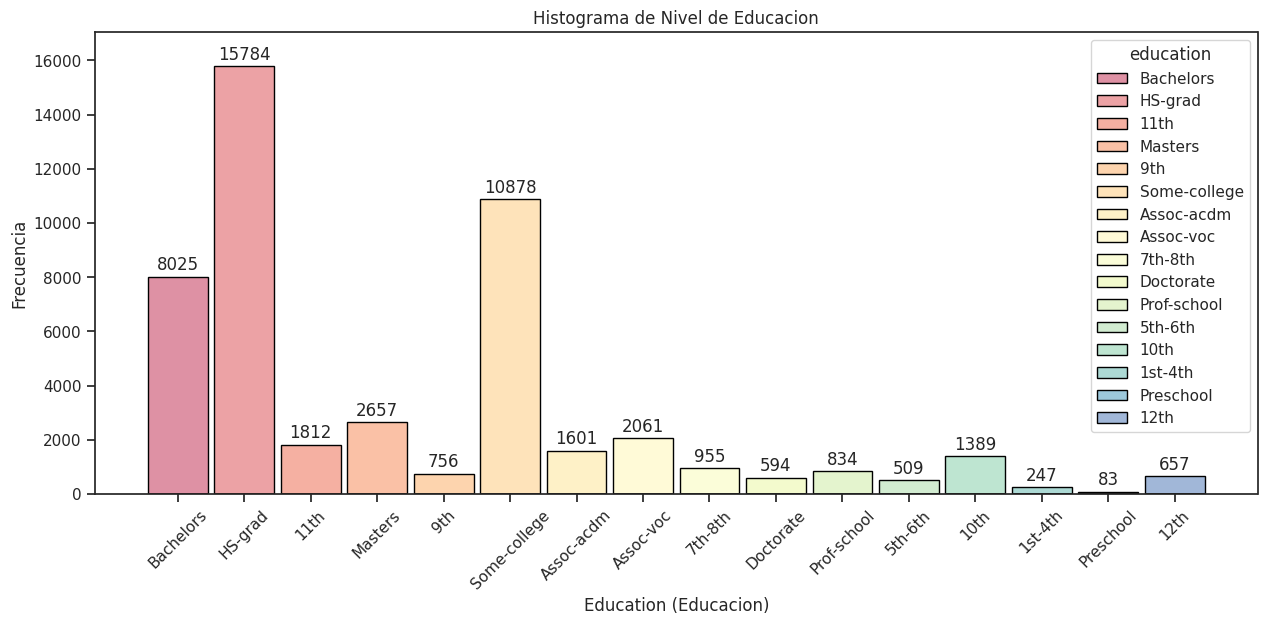

In [ ]:
# Histograma de Nivel de Educacion
sns.set_theme(style="ticks")
plt.figure(figsize=(15, 6))
ax = sns.histplot(data=df, x='education', hue='education', palette='Spectral', shrink=0.9, edgecolor='black')
plt.title('Histograma de Nivel de Educacion')
plt.xlabel('Education (Educacion)')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, padding=2,  fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
plt.ylim(0, df['education'].value_counts().max() * 1.08)
plt.show()

Para el nivel de educacion tambien se eligio un histograma, por la facilidad para visualizar las frecuencias de cada nivel educativo que tienen los ciudadanos, pudiendonos percatar de que los niveles educativos mas comunes dentro de la poblacion son:

1. HS-grand
2. Some-college
3. Bachelors

1. **¿Qué valor del atributo es el más abundante? ¿Qué interpretación demográfica se puede hacer de esto?**: El nivel de educacion mas comun es HS-grand, esto nos indica demograficamente que aproximadamente un 32% de los registros del censo como nivel educativo tienen Graduado de secundaria.

2. **¿Hay datos vacíos o no disponibles del atributo? ¿Cómo se reconocen?**: No, no hay ni valores nulos ni desconocidos.

3. **Si hay datos incompletos, ¿son una porción significativa o no? (se podría asumir que una "porción significativa" es superior al 10%)**: No hay valores nulos ni desconocidos

4. **Viendo los datos del histograma, ¿se podrían reemplazar los vacíos por el más abundante o eso generaría alguna alteración significativa?**: No hay valores nulos ni desconocidos

In [ ]:
# Correlacion entre Education y Education-num
education_correlation = df[['education', 'education-num']].drop_duplicates().sort_values(by='education-num')
display(education_correlation)

,education,education-num
224,Preschool,1
160,1st-4th,2
56,5th-6th,3
15,7th-8th,4
6,9th,5
77,10th,6
3,11th,7
415,12th,8
2,HS-grad,9
10,Some-college,10


Ademas hicimos una tabla de equivalencia entre el nivel de educacion y el numero asignado al nivel de educacion dentro del dataset esto para tener una mayor claridad en analicis futuros que requieran utilizar el valor numerico en ves del valor categorico.

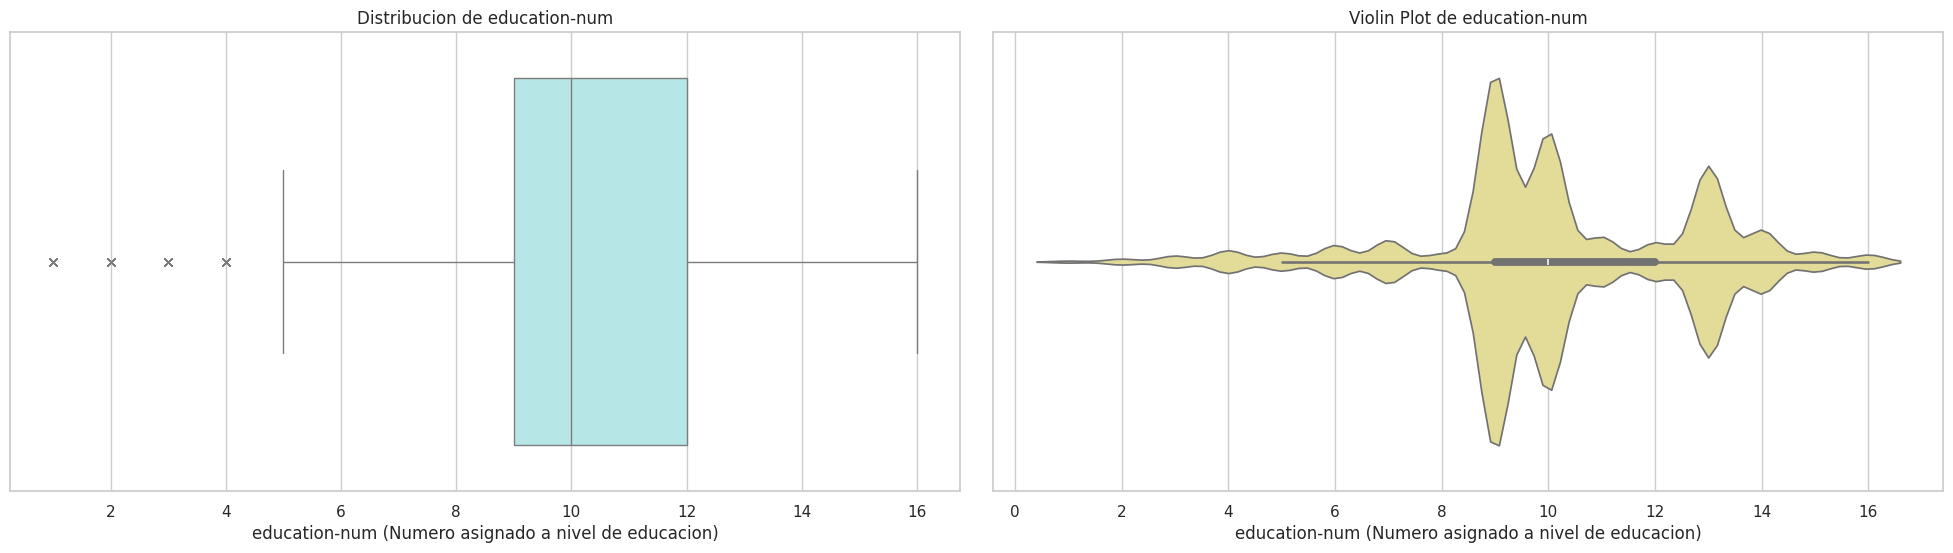

In [ ]:
# Distribucion de education-num (Numero asignado a nivel de educacion)
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(figsize=(20, 6), ncols=2, nrows=1)

sns.boxplot(data=df,x= 'education-num', color='paleturquoise', flierprops={"marker": "x"}, ax=axs[0])
axs[0].set_title('Distribucion de education-num')
axs[0].set_xlabel('education-num (Numero asignado a nivel de educacion)')

sns.violinplot(data=df, x='education-num', inner='box', color='khaki', ax=axs[1])
axs[1].set_title('Violin Plot de education-num')
axs[1].set_xlabel('education-num (Numero asignado a nivel de educacion)')

plt.tight_layout(pad=2.0) # Adjusted padding for spacing
plt.show()

Con el grafico de caja podemos ver como se agrupan las distribuciones de los niveles de educacion, esta vez asignados a valores numericos, dentro del violin plot se puede apreciar mas graficamente como hay picos entre los niveles educativos mas cumnes:

1. 9: HS-grad
2. 10: Some College
3. 13: Bachelors

In [ ]:
# # Calcular estadísticas descriptivas para 'education-num' excluyendo valores atípicos
Q1 = df['education-num'].quantile(0.25)
Q2 = df['education-num'].quantile(0.50)
Q3 = df['education-num'].quantile(0.75)
IQR = Q3 - Q1

# Filtrar valores atípicos
df_filtered_education_num = df[(df['education-num'] >= (Q1 - 1.5 * IQR)) & (df['education-num'] <= (Q3 + 1.5 * IQR))]

# Calcular estadísticas en los datos filtrados
min_education_num = df_filtered_education_num['education-num'].min()
max_education_num = df_filtered_education_num['education-num'].max()

# Calculamos outliers, definimos las barbas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar valores atípicos
outliers = df[(df['education-num'] < lower_bound) | (df['education-num'] > upper_bound)]

# Calcular el número de valores atípicos
num_outliers = outliers.shape[0]

# Calcular el porcentaje de valores atípicos
percentage_outliers = (num_outliers / df.shape[0]) * 100

# Obtener el rango de valores atípicos
min_outlier_value = outliers['education-num'].min() if num_outliers > 0 else None
max_outlier_value = outliers['education-num'].max() if num_outliers > 0 else None

range_outliers = {"max_value":max_outlier_value , "min_value":min_outlier_value}

# Crear una tabla (DataFrame) para mostrar los resultados
education_num_stats = pd.DataFrame({
    'Estadisticas': ['Q1', 'Mediana (Q2)', 'Q3', 'IQR', 'Min (excluyendo outliers)', 'Max (excluyendo outliers)','Num Outliers','% outliers','Rango Outliers'],
    'Valor': [Q1, Q2, Q3, IQR, min_education_num, max_education_num,num_outliers,percentage_outliers,range_outliers]
})

display(education_num_stats)

,Estadisticas,Valor
0,Q1,9.0
1,Mediana (Q2),10.0
2,Q3,12.0
3,IQR,3.0
4,Min (excluyendo outliers),5
5,Max (excluyendo outliers),16
6,Num Outliers,1794
7,% outliers,3.673068
8,Rango Outliers,"{'max_value': 4, 'min_value': 1}"


De la distribución de valores visible en el boxplot de 'education-num', se puede interpretar lo siguiente:

*   La caja central representa el rango intercuartílico (IQR), que contiene el 50% central de los datos de 'education-num'. La mediana (línea dentro de la caja) se encuentra alrededor de 10.0. Esto indica que la mitad de la población censada tiene un nivel educativo numérico entre 9.0 y 12.0 (aproximadamente, según los cuartiles calculados anteriormente), lo que corresponde a niveles educativos de "HS-grad" a "Assoc-acdm".
*   Las barbas se extienden desde los bordes de la caja hasta los valores máximo y mínimo dentro de 1.5 veces el rango intercuartílico desde los cuartiles. Esto muestra la dispersión de la mayoría de los datos.
*   Los puntos marcados con "x" fuera de las barbas son considerados valores atípicos (outliers). En este caso, hay varios valores atípicos en el extremo inferior de la distribución de 'education-num'.

Lo más llamativo de la distribución de estos valores es la presencia de estos valores atípicos en los niveles educativos numéricos más bajos. Aunque representan un porcentaje pequeño de la población (aproximadamente 3.67%), su existencia muestra que hay una porción de individuos con niveles educativos significativamente más bajos que la mayoría de la muestra, lo cual es visible en el boxplot como puntos dispersos por debajo de la barba inferior. La distribución general se ve ligeramente sesgada hacia niveles educativos numéricos más altos, con la mediana más cercana al primer cuartil que al tercero.

In [ ]:
df['education-num'].describe()

,education-num
count,48842.000000
mean,10.078089
std,2.570973
min,1.000000
25%,9.000000
50%,10.000000
75%,12.000000
max,16.000000


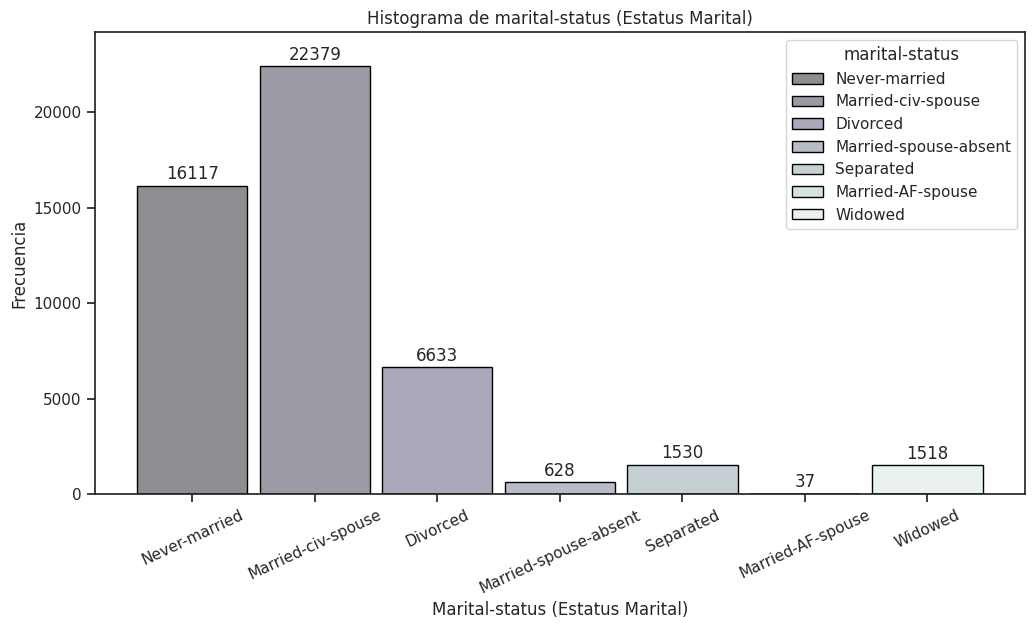

In [ ]:
# Histograma de Marital-status (Estatus Marital)
sns.set_theme(style="ticks")
plt.figure(figsize=(12, 6))
ax = sns.histplot(data=df, x='marital-status', hue='marital-status', palette='bone', shrink=0.9, edgecolor='black')
plt.title('Histograma de marital-status (Estatus Marital)')
plt.xlabel('Marital-status (Estatus Marital)')
plt.ylabel('Frecuencia')
plt.xticks(rotation=25)
for container in ax.containers:
    ax.bar_label(container, padding=2,  fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
plt.ylim(0, df['marital-status'].value_counts().max() * 1.08)
plt.show()

Eligi un histograma para representar los datos de Estatus marital, a traves de este grafico podemos observar como la mayoria de los ciudadanos censados se agrupan en tres estados principales:

1. Married-civ-spouse
2. Never-married
3. Divorced

1. **¿Qué valor del atributo es el más abundante? ¿Qué interpretación demográfica se puede hacer de esto?**: El estatus marital mas comun es Married-civ-spouse (Casado/a con cónyuge civil), esto nos puede indicar demograficamente que aproximadamente un 45% de los registros del censo estan cados con cónyuge civil

2. **¿Hay datos vacíos o no disponibles del atributo? ¿Cómo se reconocen?**: No, no hay ni valores nulos ni desconocidos.

3. **Si hay datos incompletos, ¿son una porción significativa o no? (se podría asumir que una "porción significativa" es superior al 10%)**: No hay valores nulos ni desconocidos

4. **Viendo los datos del histograma, ¿se podrían reemplazar los vacíos por el más abundante o eso generaría alguna alteración significativa?**: No hay valores nulos ni desconocidos

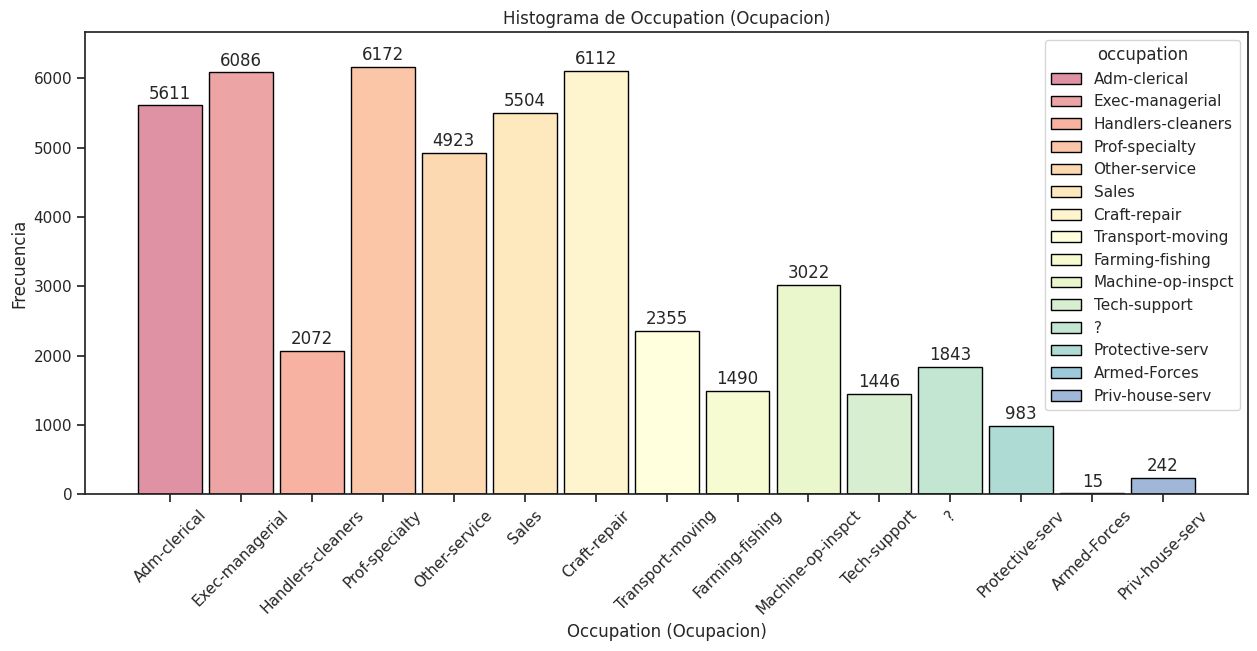

In [ ]:
# Histograma de Occupation (Ocupacion)
sns.set_theme(style="ticks")
plt.figure(figsize=(15, 6))
ax = sns.histplot(data=df, x='occupation', hue='occupation', palette='Spectral', shrink=0.9, edgecolor='black')
plt.title('Histograma de Occupation (Ocupacion)')
plt.xlabel('Occupation (Ocupacion)')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, padding=2,  fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
plt.ylim(0, df['occupation'].value_counts().max() * 1.08)
plt.show()

Como el resto de atributos categoricos para la ocupacion hemos elegido un histograma para la reprecentacion real, podemos observar que las principales ocupaciones no tienen tanta diferencia entre si, las ocupaciones mas comunes son:

1. prof-specialty
2. craft-repair
3. exec-managerial
4. adm-clerical
5. sales

1. **¿Qué valor del atributo es el más abundante? ¿Qué interpretación demográfica se puede hacer de esto?**: La ocupacion mas comun es prof-speciality (Profesionales especializados), sin embargo demograficamente podemos concluir que es la profesion mas comun pero sin tanta diferencia a comparacion de las demas profesiones ya que hay varias profesiones con una frecuencia similar

2. **¿Hay datos vacíos o no disponibles del atributo? ¿Cómo se reconocen?**: Si, dentro de este atributo hay tanto nulos como valores desconocidos señalados con '?'

3. **Si hay datos incompletos, ¿son una porción significativa o no? (se podría asumir que una "porción significativa" es superior al 10%)**: Los nulos solo representan aproximadamente un 1.9% de los registros, mientras que los valores desconocidos representan un 3.7% de los registro aproximadamente, entre los dos solo representan un 5% de los registros en total.

4. **Viendo los datos del histograma, ¿se podrían reemplazar los vacíos por el más abundante o eso generaría alguna alteración significativa?**: Creo que no es pruedente rellenar los valores nulos con la variable mas comun, ya que esto puede distorcionar las estadisticas y ademas ya se esta manejando los valores desconocidos con '?'.

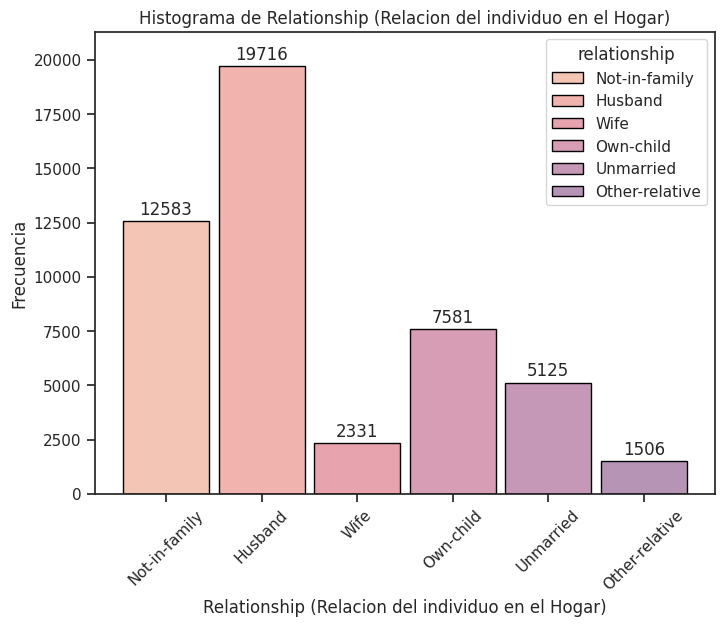

In [ ]:
# Histograma de relationship (Relacion del individuo en el Hogar)
sns.set_theme(style="ticks")
plt.figure(figsize=(8, 6))
ax = sns.histplot(data=df, x='relationship', hue='relationship', palette='flare', shrink=0.9, edgecolor='black')
plt.title('Histograma de Relationship (Relacion del individuo en el Hogar)')
plt.xlabel('Relationship (Relacion del individuo en el Hogar)')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, padding=2,  fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
plt.ylim(0, df['relationship'].value_counts().max() * 1.08)
plt.show()

El histograma de relacion del individuo en el hogar nos deja ver que la mayoria de los censados son esposos o no estan en familia

1. **¿Qué valor del atributo es el más abundante? ¿Qué interpretación demográfica se puede hacer de esto?**: La relacion del individuo en el hogar mas comun es Husband (Esposo), esto nos indica demograficamente que aproximadamente un 40% de los registros indicaba que su relacion en el hogar era ser esposo

2. **¿Hay datos vacíos o no disponibles del atributo? ¿Cómo se reconocen?**: No, no hay ni valores nulos ni desconocidos.

3. **Si hay datos incompletos, ¿son una porción significativa o no? (se podría asumir que una "porción significativa" es superior al 10%)**: No hay valores nulos ni desconocidos

4. **Viendo los datos del histograma, ¿se podrían reemplazar los vacíos por el más abundante o eso generaría alguna alteración significativa?**: No hay valores nulos ni desconocidos

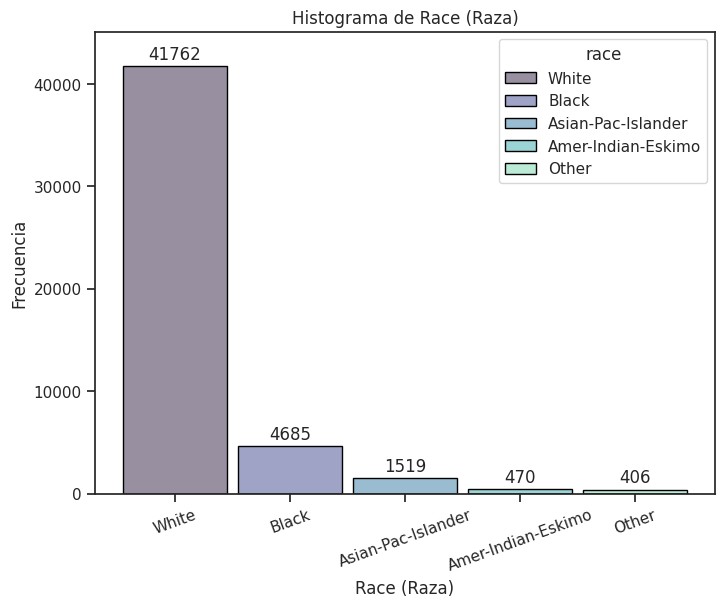

In [ ]:
# Histograma de Race (Raza)
sns.set_theme(style="ticks")
plt.figure(figsize=(8, 6))
ax = sns.histplot(data=df, x='race', hue='race', palette='mako', shrink=0.9, edgecolor='black')
plt.title('Histograma de Race (Raza)')
plt.xlabel('Race (Raza)')
plt.ylabel('Frecuencia')
plt.xticks(rotation=20)
for container in ax.containers:
    ax.bar_label(container, padding=2,  fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
plt.ylim(0, df['race'].value_counts().max() * 1.08)
plt.show()

En el histograma de Raza podemos ver que la mayoria de censados es blancos

1. **¿Qué valor del atributo es el más abundante? ¿Qué interpretación demográfica se puede hacer de esto?**: La mayoria de los registros de Raza es blanco, esto nos indica demograficamente que practicamente un 85% de los registros del censo corresponden a personas de raza blanca

2. **¿Hay datos vacíos o no disponibles del atributo? ¿Cómo se reconocen?**: No, no hay ni valores nulos ni desconocidos.

3. **Si hay datos incompletos, ¿son una porción significativa o no? (se podría asumir que una "porción significativa" es superior al 10%)**: No hay valores nulos ni desconocidos

4. **Viendo los datos del histograma, ¿se podrían reemplazar los vacíos por el más abundante o eso generaría alguna alteración significativa?**: No hay valores nulos ni desconocidos

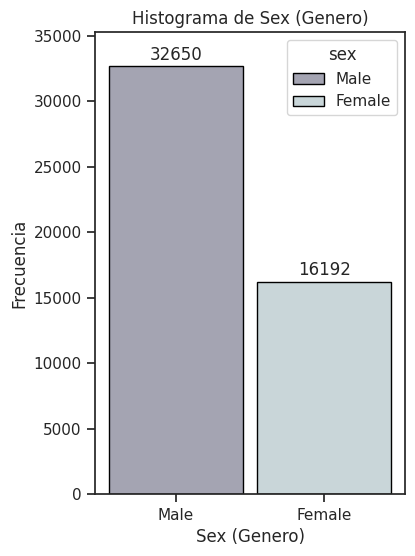

In [ ]:
# Histograma de Sex (Genero)
sns.set_theme(style="ticks")
plt.figure(figsize=(4, 6))
ax = sns.histplot(data=df, x='sex', hue='sex', palette='bone', shrink=0.9, edgecolor='black')
plt.title('Histograma de Sex (Genero)')
plt.xlabel('Sex (Genero)')
plt.ylabel('Frecuencia')
for container in ax.containers:
    ax.bar_label(container, padding=2,  fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
plt.ylim(0, df['sex'].value_counts().max() * 1.08)
plt.show()

En el histograma de sexo podemos ver como la mayoria de ciudadanos censados eran hombres duplicando la cantidad de mujeres

1. **¿Qué valor del atributo es el más abundante? ¿Qué interpretación demográfica se puede hacer de esto?**: El genero mas comun es Male (Hombre) esto nos indica demograficamente que un 66% de los registros aproximadamente son hombres

2. **¿Hay datos vacíos o no disponibles del atributo? ¿Cómo se reconocen?**: No, no hay ni valores nulos ni desconocidos.

3. **Si hay datos incompletos, ¿son una porción significativa o no? (se podría asumir que una "porción significativa" es superior al 10%)**: No hay valores nulos ni desconocidos

4. **Viendo los datos del histograma, ¿se podrían reemplazar los vacíos por el más abundante o eso generaría alguna alteración significativa?**: No hay valores nulos ni desconocidos

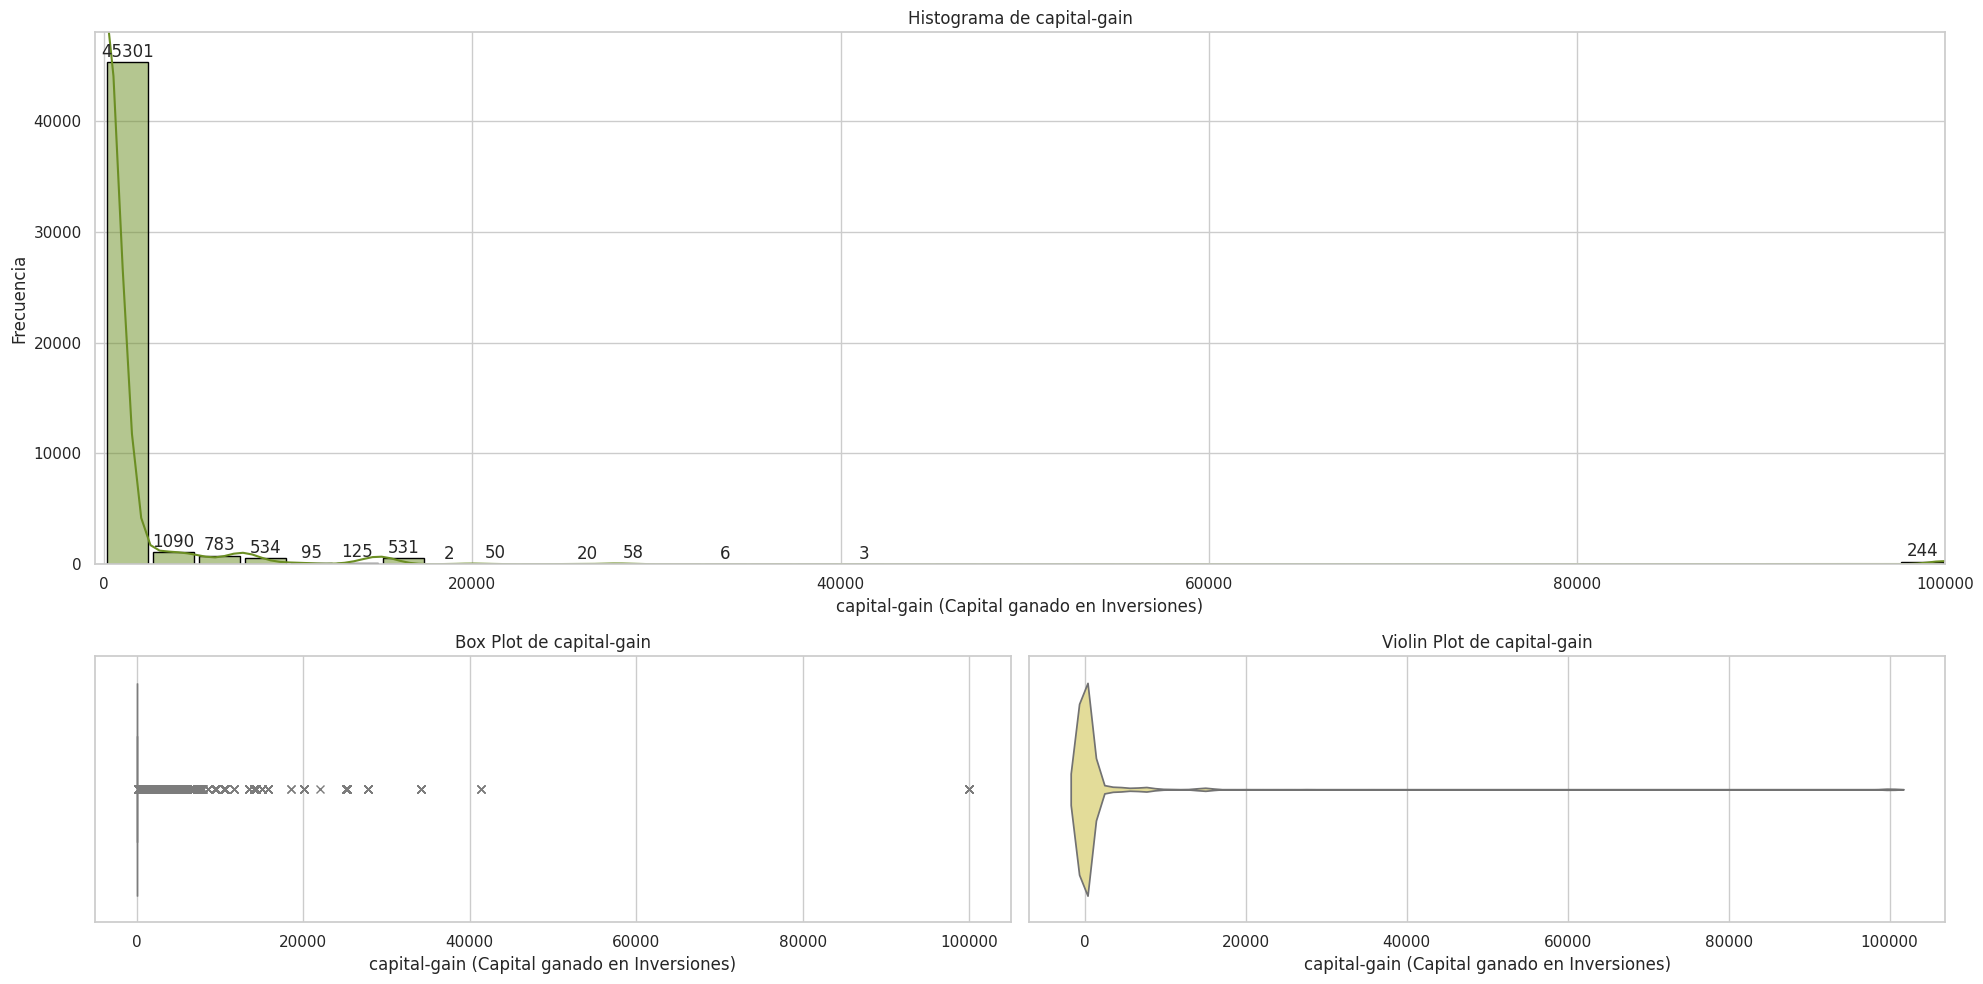

In [ ]:
# Distribucion de Capital-Gain (Capital ganado en Inversiones)
import matplotlib.gridspec as gridspec

sns.set_theme(style="whitegrid")

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[2,1])

# Histograma en la primera fila, abarcando ambas columnas
ax1 = fig.add_subplot(gs[0, :])
sns.histplot(data=df, x='capital-gain', bins=40, kde=True, color='olivedrab', shrink=0.9, edgecolor='black', ax=ax1)
ax1.set_title('Histograma de capital-gain')
ax1.set_xlabel('capital-gain (Capital ganado en Inversiones)')
ax1.set_ylabel('Frecuencia')
for container in ax1.containers:
    ax1.bar_label(container, padding=1,  fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])

# Set x-axis limit to remove blank space
ax1.set_xlim(-500,100000)
ax1.set_ylim(0,48000)


# Boxplot en la segunda fila, primera columna
ax2 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=df, x='capital-gain', color='paleturquoise', flierprops={"marker": "x"}, ax=ax2)
ax2.set_title('Box Plot de capital-gain')
ax2.set_xlabel('capital-gain (Capital ganado en Inversiones)')


# Violin Plot en la segunda fila, segunda columna
ax3 = fig.add_subplot(gs[1, 1])
sns.violinplot(data=df, x='capital-gain', inner=None, color='khaki', ax=ax3)
ax3.set_title('Violin Plot de capital-gain')
ax3.set_xlabel('capital-gain (Capital ganado en Inversiones)')

plt.tight_layout()
plt.show()

Para los atributos capital-gain como capital-loss decidi hacer 3 graficos para representar sus valores, un histograma, un grafico de caja y un violinplot, esto para poder darnos una mejor idea de como se distribuyen los datos.

A priori nos podemos dar cuenta que hay una gran cantidad de personas que no reportan ninguna ganancia en inversiones, esto nos podria indicar al cruzar los datos con capital-loss que una gran cantidad de personas no ha ganado ni perdido dinero lo que indicaria que jamas ha hecho una inversion.

Tambien podemos notar que la ganancia maxima en inversiones esta cerca de los $100000 dolares

In [ ]:
# Calcular estadísticas descriptivas para 'capital-gain' excluyendo valores atípicos
Q1 = df['capital-gain'].quantile(0.25)
Q2 = df['capital-gain'].quantile(0.50)
Q3 = df['capital-gain'].quantile(0.75)
IQR = Q3 - Q1

# Filtrar valores atípicos
df_filtered_capital_gain = df[(df['capital-gain'] >= (Q1 - 1.5 * IQR)) & (df['capital-gain'] <= (Q3 + 1.5 * IQR))]

# Calcular estadísticas en los datos filtrados
min_capital_gain = df_filtered_capital_gain['capital-gain'].min()
max_capital_gain = df_filtered_capital_gain['capital-gain'].max()

# Calculamos outliers, definimos las barbas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar valores atípicos
outliers = df[(df['capital-gain'] < lower_bound) | (df['capital-gain'] > upper_bound)]

# Calcular el número de valores atípicos
num_outliers = outliers.shape[0]

# Calcular el porcentaje de valores atípicos
percentage_outliers = (num_outliers / df.shape[0]) * 100

# Obtener el rango de valores atípicos
min_outlier_value = outliers['capital-gain'].min() if num_outliers > 0 else None
max_outlier_value = outliers['capital-gain'].max() if num_outliers > 0 else None

range_outliers = {"max_value":max_outlier_value , "min_value":min_outlier_value}

# Crear una tabla (DataFrame) para mostrar los resultados
capital_gain_stats = pd.DataFrame({
    'Estadisticas': ['Q1', 'Mediana (Q2)', 'Q3', 'IQR', 'Min (excluyendo outliers)', 'Max (excluyendo outliers)','Num Outliers','% outliers','Rango Outliers'],
    'Valor': [Q1, Q2, Q3, IQR, min_capital_gain, max_capital_gain ,num_outliers,percentage_outliers,range_outliers]
})

display(capital_gain_stats)

,Estadisticas,Valor
0,Q1,0.0
1,Mediana (Q2),0.0
2,Q3,0.0
3,IQR,0.0
4,Min (excluyendo outliers),0
5,Max (excluyendo outliers),0
6,Num Outliers,4035
7,% outliers,8.261332
8,Rango Outliers,"{'max_value': 99999, 'min_value': 114}"


De la distribución de valores visible en el boxplot de 'capital-gain', se puede interpretar lo siguiente:

*   La caja central representa el rango intercuartílico (IQR), que contiene el 50% central de los datos de 'capital-gain'. La mediana (línea dentro de la caja) se encuentra en 0.0. Esto indica que la mitad de la población censada no tuvo ganancias de capital.
*   Las barbas se extienden desde los bordes de la caja hasta los valores máximo y mínimo dentro de 1.5 veces el rango intercuartílico desde los cuartiles. En este caso, debido a que la mayoría de los valores son 0, las barbas son muy cortas.
*   Los puntos marcados con "x" fuera de las barbas son considerados valores atípicos (outliers). En este caso, hay un número significativo de valores atípicos en el extremo superior de la distribución de 'capital-gain'.

Lo más llamativo de la distribución de estos valores es la gran concentración de valores en 0, lo que indica que la mayoría de las personas en el censo no reportaron ninguna ganancia de capital. La presencia de valores atípicos en el extremo superior muestra que hay un pequeño grupo de individuos con ganancias de capital significativamente altas en comparación con la mayoría de la población.

In [ ]:
df['capital-gain'].describe()

,capital-gain
count,48842.000000
mean,1079.067626
std,7452.019058
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,99999.000000


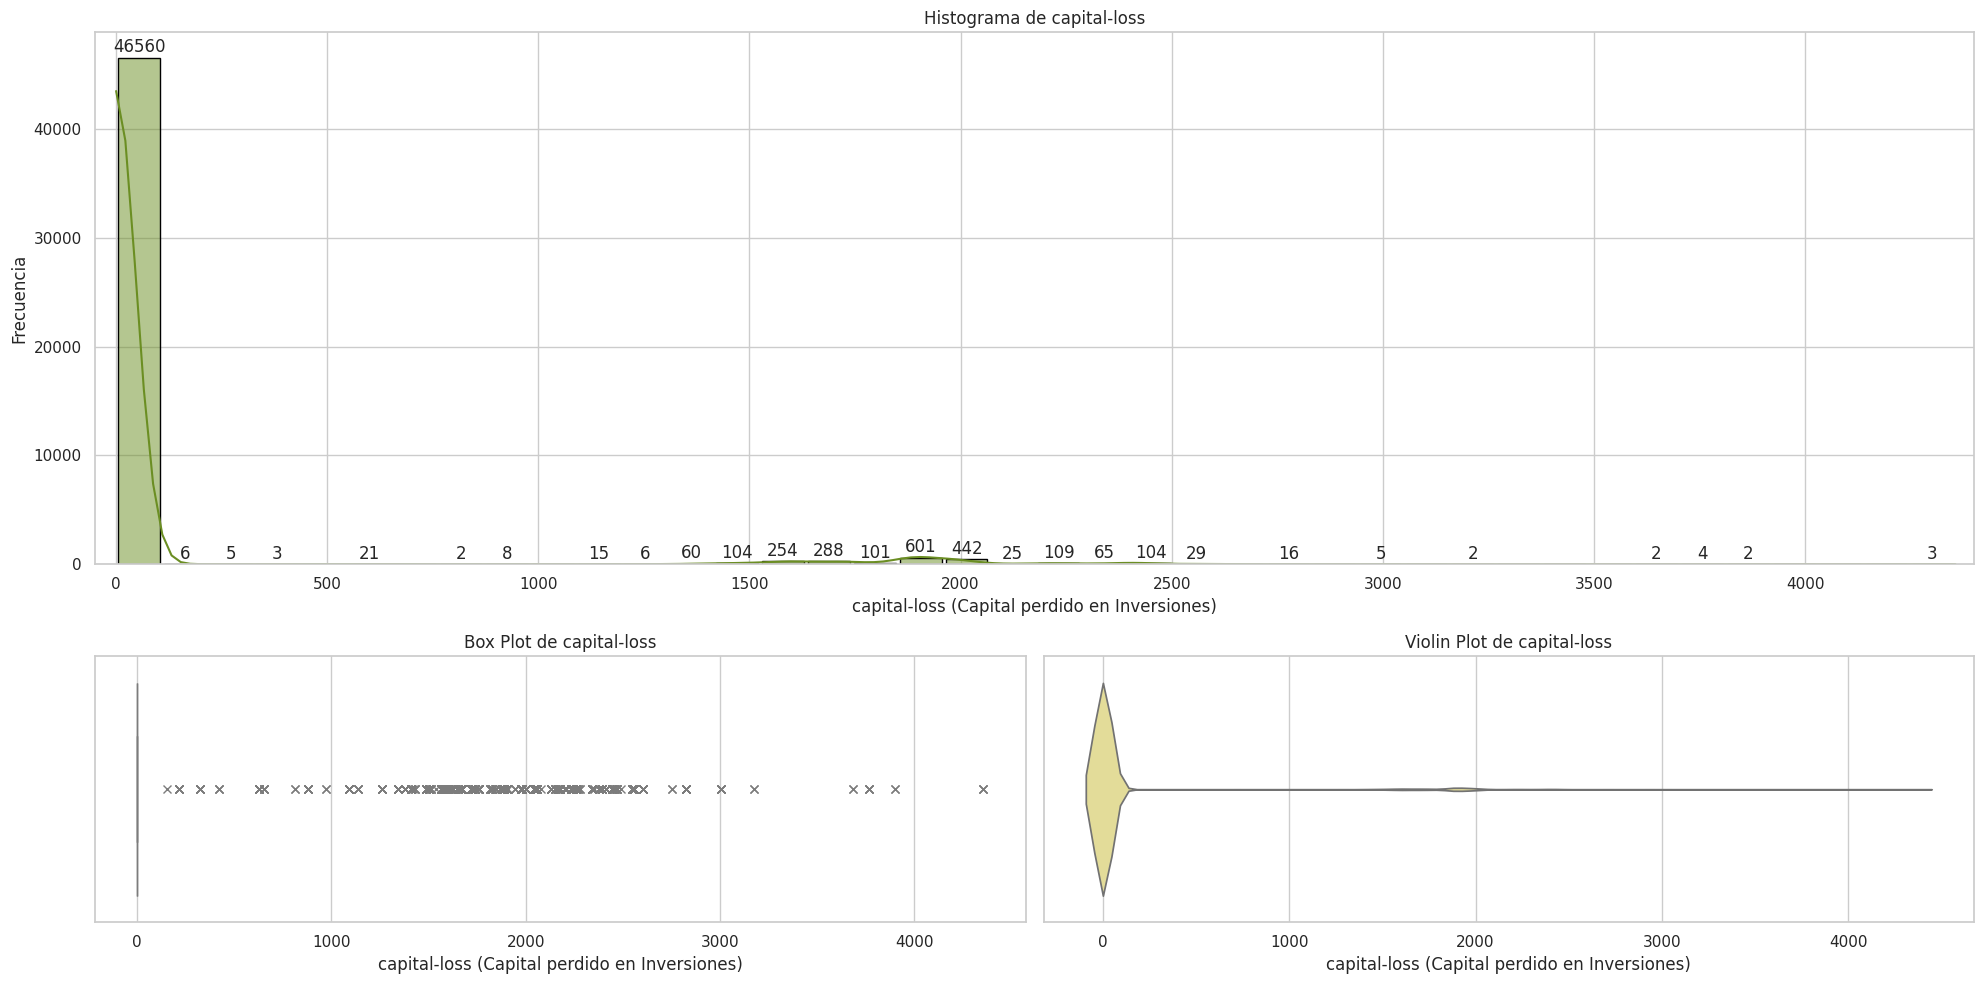

In [ ]:
# Distribucion de Capital-Loss (Capital Perdido en Inversiones)
import matplotlib.gridspec as gridspec

sns.set_theme(style="whitegrid")

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[2,1])

# Histograma en la primera columna
ax1 = fig.add_subplot(gs[0, :])
sns.histplot(data=df, x='capital-loss', bins=40, kde=True, color='olivedrab', shrink=0.9, edgecolor='black', ax=ax1)
ax1.set_title('Histograma de capital-loss')
ax1.set_xlabel('capital-loss (Capital perdido en Inversiones)')
ax1.set_ylabel('Frecuencia')
for container in ax1.containers:
    ax1.bar_label(container, padding=1,  fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])

# Set x-axis limit to remove blank space
ax1.set_xlim(-50,4400)

# Boxplot en la segunda columna, primera fila
ax2 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=df, x='capital-loss', color='paleturquoise', flierprops={"marker": "x"}, ax=ax2)
ax2.set_title('Box Plot de capital-loss')
ax2.set_xlabel('capital-loss (Capital perdido en Inversiones)')


# Violin Plot en la segunda columna, segunda fila
ax3 = fig.add_subplot(gs[1, 1])
sns.violinplot(data=df, x='capital-loss', inner=None, color='khaki', ax=ax3)
ax3.set_title('Violin Plot de capital-loss')
ax3.set_xlabel('capital-loss (Capital perdido en Inversiones)')

plt.tight_layout()
plt.show()

En los graficos a simple vista nos podemos dar cuenta que para capital-loss las perdidas ocupan un rango mucho menor que apenas se hacerca a los 4500 dolares para las mayores perdidas en inversiones a comparacion de las mayores ganancias en inversiones que estan cerca de los $100000 dolares

In [ ]:
# Calcular estadísticas descriptivas para 'capital-loss' excluyendo valores atípicos
Q1 = df['capital-loss'].quantile(0.25)
Q2 = df['capital-loss'].quantile(0.50)
Q3 = df['capital-loss'].quantile(0.75)
IQR = Q3 - Q1

# Filtrar valores atípicos
df_filtered_capital_loss = df[(df['capital-loss'] >= (Q1 - 1.5 * IQR)) & (df['capital-loss'] <= (Q3 + 1.5 * IQR))]

# Calcular estadísticas en los datos filtrados
min_capital_loss = df_filtered_capital_loss['capital-loss'].min()
max_capital_loss = df_filtered_capital_loss['capital-loss'].max()

# Calculamos outliers, definimos las barbas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar valores atípicos
outliers = df[(df['capital-loss'] < lower_bound) | (df['capital-loss'] > upper_bound)]

# Calcular el número de valores atípicos
num_outliers = outliers.shape[0]

# Calcular el porcentaje de valores atípicos
percentage_outliers = (num_outliers / df.shape[0]) * 100

# Obtener el rango de valores atípicos
min_outlier_value = outliers['capital-loss'].min() if num_outliers > 0 else None
max_outlier_value = outliers['capital-loss'].max() if num_outliers > 0 else None

range_outliers = {"max_value":max_outlier_value , "min_value":min_outlier_value}

# Crear una tabla (DataFrame) para mostrar los resultados
capital_loss_stats = pd.DataFrame({
    'Estadisticas': ['Q1', 'Mediana (Q2)', 'Q3', 'IQR', 'Min (excluyendo outliers)', 'Max (excluyendo outliers)','Num Outliers','% outliers','Rango Outliers'],
    'Valor': [Q1, Q2, Q3, IQR, min_capital_loss, max_capital_loss,num_outliers,percentage_outliers,range_outliers]
})

display(capital_loss_stats)

,Estadisticas,Valor
0,Q1,0.0
1,Mediana (Q2),0.0
2,Q3,0.0
3,IQR,0.0
4,Min (excluyendo outliers),0
5,Max (excluyendo outliers),0
6,Num Outliers,2282
7,% outliers,4.672208
8,Rango Outliers,"{'max_value': 4356, 'min_value': 155}"


De la distribución de valores visible en el boxplot de 'capital-loss', se puede interpretar lo siguiente:

*   La caja central representa el rango intercuartílico (IQR), que contiene el 50% central de los datos de 'capital-loss'. La mediana (línea dentro de la caja) se encuentra en 0.0. Esto indica que la mitad de la población censada no tuvo pérdidas de capital.
*   Las barbas se extienden desde los bordes de la caja hasta los valores máximo y mínimo dentro de 1.5 veces el rango intercuartílico desde los cuartiles. Similar a 'capital-gain', debido a la alta concentración de valores en 0, las barbas son muy cortas.
*   Los puntos marcados con "x" fuera de las barbas son considerados valores atípicos (outliers). En este caso, hay un número significativo de valores atípicos en el extremo superior de la distribución de 'capital-loss'.

Lo más llamativo de la distribución de estos valores es, al igual que en 'capital-gain', la gran concentración de valores en 0, lo que indica que la mayoría de las personas en el censo no reportaron ninguna pérdida de capital. La presencia de valores atípicos en el extremo superior muestra que hay un pequeño grupo de individuos con pérdidas de capital significativamente altas en comparación con la mayoría de la población, aunque el rango de pérdidas es mucho menor que el de las ganancias.

In [ ]:
df['capital-loss'].describe()

,capital-loss
count,48842.000000
mean,87.502314
std,403.004552
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,4356.000000


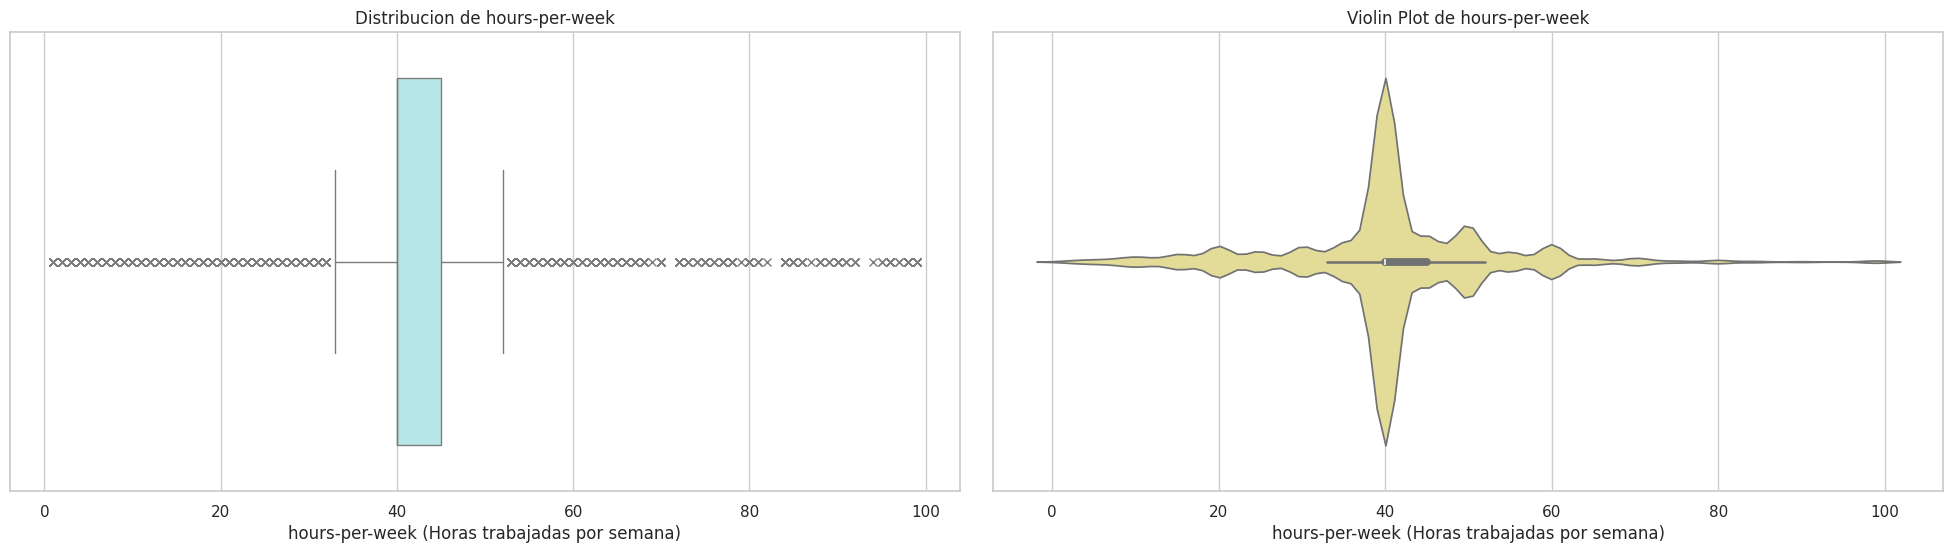

In [ ]:
# Distribucion de hours-per-week (horas trabajadas por semana)
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(figsize=(20, 6), ncols=2, nrows=1)

sns.boxplot(data=df,x= 'hours-per-week', color='paleturquoise', flierprops={"marker": "x"}, ax=axs[0])
axs[0].set_title('Distribucion de hours-per-week')
axs[0].set_xlabel('hours-per-week (Horas trabajadas por semana)')

sns.violinplot(data=df, x='hours-per-week', inner='box', color='khaki', ax=axs[1])
axs[1].set_title('Violin Plot de hours-per-week')
axs[1].set_xlabel('hours-per-week (Horas trabajadas por semana)')

plt.tight_layout(pad=2.0) # Adjusted padding for spacing
plt.show()

Para visualizar los datos que corresponden a las horas trabajadas por semanas, se eligieron un grafico de caja y uno de violin, ya que estos dos graficos nos ayudan a enteender mejor como se distribuyen las horas trabajadas por semanas entre los participantes del censo, ademas de ayudarnos a identificar valores atipicos (marcados con x en el boxplot)

En general podemos notar como la mayoria de los encuestado trabajan entre 40 y 45 horas

In [ ]:
# Calcular estadísticas descriptivas para 'hours-per-week' excluyendo valores atípicos
Q1 = df['hours-per-week'].quantile(0.25)
Q2 = df['hours-per-week'].quantile(0.50)
Q3 = df['hours-per-week'].quantile(0.75)
IQR = Q3 - Q1

# Filtrar valores atípicos
df_filtered_hours_per_week = df[(df['hours-per-week'] >= (Q1 - 1.5 * IQR)) & (df['hours-per-week'] <= (Q3 + 1.5 * IQR))]

# Calcular estadísticas en los datos filtrados
min_hours_per_week = df_filtered_hours_per_week['hours-per-week'].min()
max_hours_per_week = df_filtered_hours_per_week['hours-per-week'].max()

# Calculamos outliers, definimos las barbas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar valores atípicos
outliers = df[(df['hours-per-week'] < lower_bound) | (df['hours-per-week'] > upper_bound)]

# Calcular el número de valores atípicos
num_outliers = outliers.shape[0]

# Calcular el porcentaje de valores atípicos
percentage_outliers = (num_outliers / df.shape[0]) * 100

# Obtener el rango de valores atípicos
min_outlier_value = outliers['hours-per-week'].min() if num_outliers > 0 else None
max_outlier_value = outliers['hours-per-week'].max() if num_outliers > 0 else None

range_outliers = {"max_value":max_outlier_value , "min_value":min_outlier_value}

# Crear una tabla (DataFrame) para mostrar los resultados
capital_hours_per_week = pd.DataFrame({
    'Estadisticas': ['Q1', 'Mediana (Q2)', 'Q3', 'IQR', 'Min (excluyendo outliers)', 'Max (excluyendo outliers)','Num Outliers','% outliers','Rango Outliers'],
    'Valor': [Q1, Q2, Q3, IQR, min_hours_per_week, max_hours_per_week,num_outliers,percentage_outliers,range_outliers]
})

display(capital_hours_per_week)

,Estadisticas,Valor
0,Q1,40.0
1,Mediana (Q2),40.0
2,Q3,45.0
3,IQR,5.0
4,Min (excluyendo outliers),33
5,Max (excluyendo outliers),52
6,Num Outliers,13496
7,% outliers,27.631956
8,Rango Outliers,"{'max_value': 99, 'min_value': 1}"


De la distribución de valores visible en el boxplot de 'hours-per-week', se puede interpretar lo siguiente:

*   La caja central representa el rango intercuartílico (IQR), que contiene el 50% central de los datos de 'hours-per-week'. La mediana (línea dentro de la caja) se encuentra en 40.0. Esto indica que la mitad de la población censada trabaja entre 40.0 y 45.0 horas por semana (aproximadamente, según los cuartiles calculados anteriormente).
*   Las barbas se extienden desde los bordes de la caja hasta los valores máximo y mínimo dentro de 1.5 veces el rango intercuartílico desde los cuartiles. Esto muestra la dispersión de la mayoría de los datos.
*   Los puntos marcados con "x" fuera de las barbas son considerados valores atípicos (outliers). En este caso, hay un número significativo de valores atípicos tanto en el extremo inferior como superior de la distribución de 'hours-per-week'.

Lo más llamativo de la distribución de estos valores es la alta concentración de datos alrededor de las 40 horas por semana, lo que sugiere que una jornada laboral de tiempo completo estándar es muy común en la población censada. La presencia de un gran número de valores atípicos en ambos extremos indica que hay una porción considerable de individuos que trabajan significativamente menos o más horas que la mayoría, los outliers representan un 27% de los registros de horas trabajadas por semana.

In [ ]:
df['hours-per-week'].describe()

,hours-per-week
count,48842.000000
mean,40.422382
std,12.391444
min,1.000000
25%,40.000000
50%,40.000000
75%,45.000000
max,99.000000


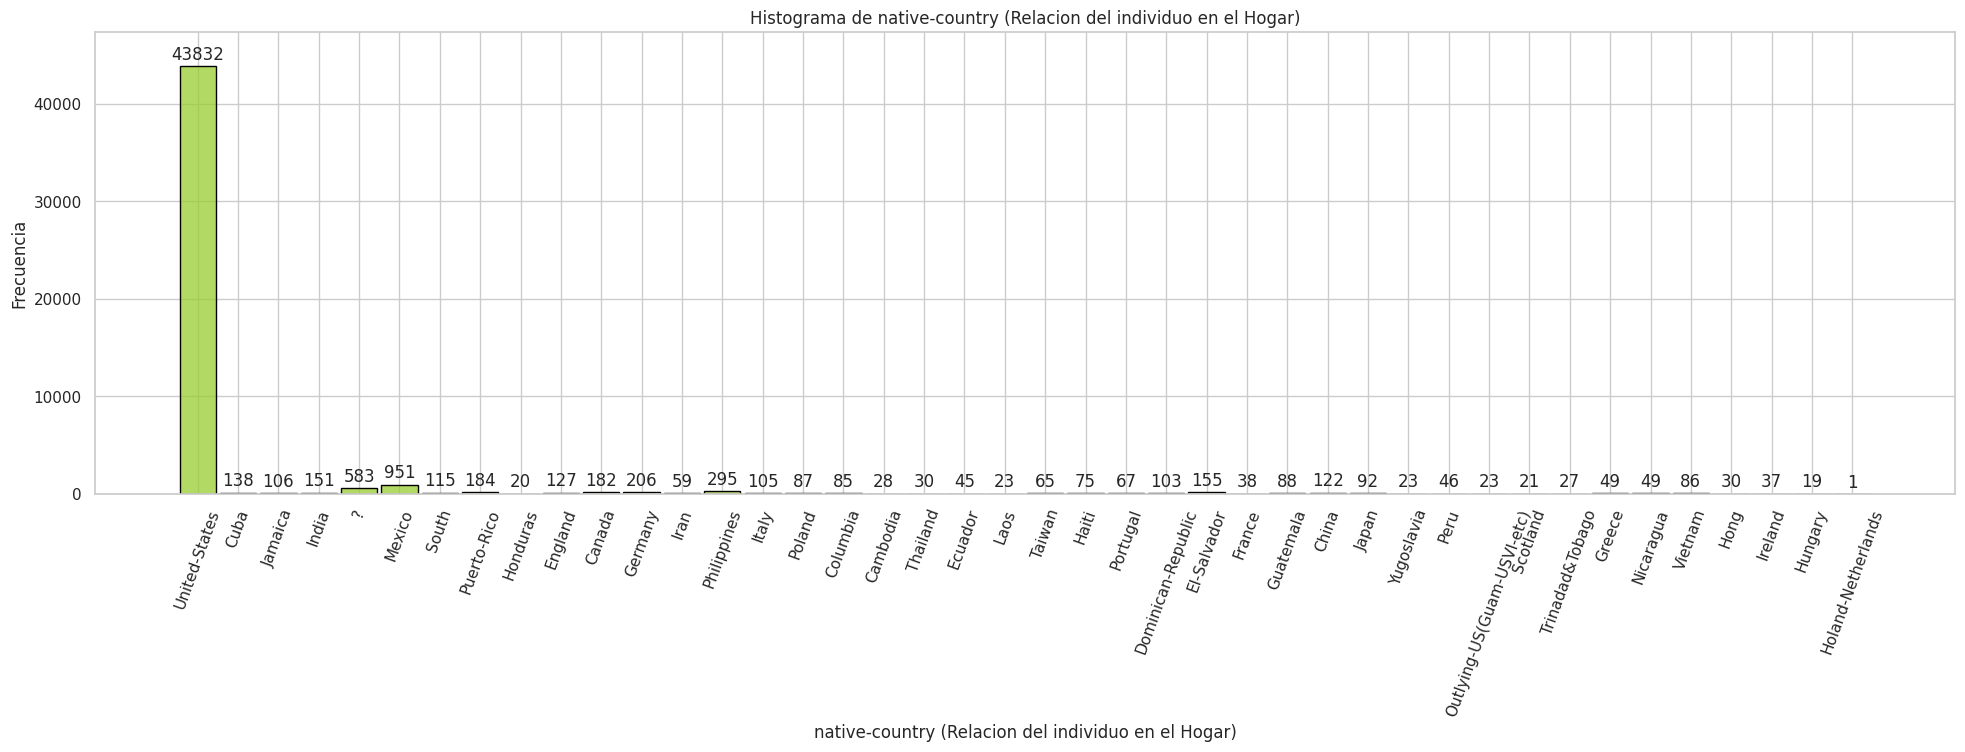

In [ ]:
# Histograma de native-country (Relacion del individuo en el Hogar)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(24, 6))
ax = sns.histplot(data=df, x='native-country', color='yellowgreen', shrink=0.9, edgecolor='black')
plt.title('Histograma de native-country (Relacion del individuo en el Hogar)')
plt.xlabel('native-country (Relacion del individuo en el Hogar)')
plt.ylabel('Frecuencia')
plt.xticks(rotation=70)
for container in ax.containers:
    ax.bar_label(container, padding=2,  fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
plt.ylim(0, df['native-country'].value_counts().max() * 1.08)
plt.show()

En el histograma de native country podemos ver como se espera que la mayoria de los encuestados su pais natal es estados unidos, ademas de esto podemos notar que hay una gran cantidad de paises natales con algunos pocos ciudadanos

1. **¿Qué valor del atributo es el más abundante? ¿Qué interpretación demográfica se puede hacer de esto?**: El pais de origen mas comun es Estados unidos, esto nos indica demograficamente que aproxiadamente un 90% de los registros del censo de pais de origen son de estados unidos lo que tiene logica ya que el censo es de estados unidos

2. **¿Hay datos vacíos o no disponibles del atributo? ¿Cómo se reconocen?**: Si, dentro de este atributo hay tanto nulos como valores desconocidos señalados con '?'

3. **Si hay datos incompletos, ¿son una porción significativa o no? (se podría asumir que una "porción significativa" es superior al 10%)**: Los nulos solo representan aproximadamente un 0.5% de los registros, mientras que los valores desconocidos representan un 1.1% de los registro aproximadamente, entre los dos solo representan un 1.6% de los registros en total.

4. **Viendo los datos del histograma, ¿se podrían reemplazar los vacíos por el más abundante o eso generaría alguna alteración significativa?**: Creo que no es pruedente rellenar los valores nulos con la variable mas comun, ya que esto puede distorcionar las estadisticas y ademas ya se esta manejando los valores desconocidos con '?'.

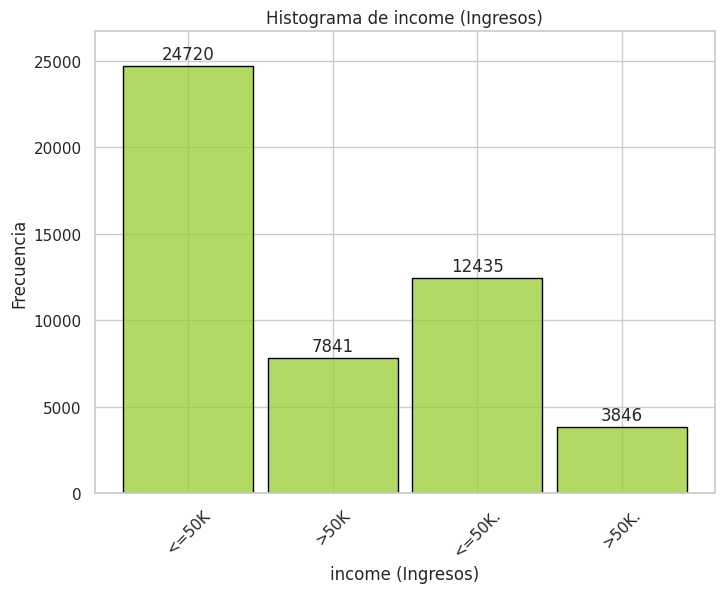

In [ ]:
# Histograma de income (Ingresos)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
ax = sns.histplot(data=df, x='income', color='yellowgreen', shrink=0.9, edgecolor='black')
plt.title('Histograma de income (Ingresos)')
plt.xlabel('income (Ingresos)')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, padding=2,  fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
plt.ylim(0, df['income'].value_counts().max() * 1.08)
plt.show()

Lo bueno de hacer una visualizacion previa de los datos es que uno puede notar errore dentro del dataset, por ejemplo aqui nos damos cuenta que hubo un error de tipeo y en algunas ocaciones se les agrego un punto final a una de las dos opciones del censo.

1. **¿Qué valor del atributo es el más abundante? ¿Qué interpretación demográfica se puede hacer de esto?**: El genero mas comun es Male (Hombre) esto nos indica demograficamente que un 66% de los registros aproximadamente son hombres

2. **¿Hay datos vacíos o no disponibles del atributo? ¿Cómo se reconocen?**: No, no hay ni valores nulos ni desconocidos.

3. **Si hay datos incompletos, ¿son una porción significativa o no? (se podría asumir que una "porción significativa" es superior al 10%)**: No hay valores nulos ni desconocidos

4. **Viendo los datos del histograma, ¿se podrían reemplazar los vacíos por el más abundante o eso generaría alguna alteración significativa?**: No hay valores nulos ni desconocidos

> En general he decidido no rellenar con el valor mas comun los valores nulos ni eliminarlos por la variable peso (fnlwgt), ahora estamos asiendo apenas una primera aproximacion a los valores del dataset solo sentrandonos en los registros, pero para analisis mas profundos va ser necesesario incorporar esta variable y ajustar los registros para que concuerden con los pesos asignados por el censo lo que podria cambiar tanto las frecuencias como distribuciones de los distintos atributos al ciertos registros presentar pesos atipicos que representan a muchisima gente lo que nos podria indicar en un futuro problemas a la hora del censo al encontrar una gran cantidad de valores desconocidos en ciertos atributos mayor a lo que se encontro a priori sin utilizar el peso.

# Valores Duplicados

In [ ]:
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")
print()
print("Descartando filas con valores duplicados...")
df = df.drop_duplicates()
print()
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Número de filas: 48842
Número de columnas: 15

Descartando filas con valores duplicados...

Número de filas: 48813
Número de columnas: 15


# Valores Nulos

In [ ]:
# Contar filas con valores nulos antes de rellenar
print("Número de filas con valores nulos antes de rellenar:")
print(df.isnull().sum().to_string())

print("\nNúmero de filas con valores '?':")
# For categorical columns, count '?'
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {(df[col] == '?').sum()}")

Número de filas con valores nulos antes de rellenar:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0

Número de filas con valores '?':
workclass: 1836
education: 0
marital-status: 0
occupation: 1843
relationship: 0
race: 0
sex: 0
native-country: 582
income: 0


In [ ]:
# posibles filas perdidas (Nulos + Valores desconocidos)
workclass_rows = 963 + 1836
occupation_rows = 966 + 1843
native_country_rows = 274 + 582
print(f"Total de posibles filas perdidas: {workclass_rows + occupation_rows + native_country_rows}")

Total de posibles filas perdidas: 6464


In [ ]:
print("Número de filas válidas por columna:")
print(df.count().to_string())

Número de filas válidas por columna:
age               48813
workclass         47850
fnlwgt            48813
education         48813
education-num     48813
marital-status    48813
occupation        47847
relationship      48813
race              48813
sex               48813
capital-gain      48813
capital-loss      48813
hours-per-week    48813
native-country    48539
income            48813


In [ ]:
# Rellenamos los valores nulos en las columnas 'native-country', 'occupation' y 'workclass' con '?'
df = df.copy()
df['native-country'] = df['native-country'].fillna('?')
df['occupation'] = df['occupation'].fillna('?')
df['workclass'] = df['workclass'].fillna('?')

print("Número de filas válidas por columna después de rellenar nulos:")
print(df.count().to_string())

Número de filas válidas por columna después de rellenar nulos:
age               48813
workclass         48813
fnlwgt            48813
education         48813
education-num     48813
marital-status    48813
occupation        48813
relationship      48813
race              48813
sex               48813
capital-gain      48813
capital-loss      48813
hours-per-week    48813
native-country    48813
income            48813


**3.1 Mirando el resultado de la instrucción siguiente, ¿Ud. optaría por corregir datos incompletos o derechamente eliminar aquellas filas (y en este caso, cuántas serían aprox)? ¿Por qué?**

Observando el resultado de la instrucción que muestra el número de filas válidas por columna, se identificaron datos incompletos (valores nulos o desconocidos marcados con '?') en las columnas 'workclass', 'occupation' y 'native-country'.

Se optó por **corregir los datos incompletos en lugar de eliminar las filas**. Las razones para esta decisión son las siguientes:

1.  **Bajo porcentaje de datos incompletos**: Como se mencionó en análisis anteriores, el porcentaje de datos incompletos en estas columnas es relativamente bajo (aproximadamente 3% para 'workclass', 5% para 'occupation' considerando nulos y '?', y 1.6% para 'native-country' considerando nulos y '?'). Eliminar todas las filas con datos incompletos (considerando nulos y desconocidos ya que los dos tipos de datos apuntan a lo mismo, no conocer la variable) resultaría en la pérdida de 6464 filas lo que representa una porción significativa del dataset total, reduciendo el tamaño de la muestra y potencialmente perdiendo información valiosa.

2.  **Consistencia en la representación de datos desconocidos**: El dataset ya utiliza el signo de interrogación '?' para representar valores desconocidos en algunos atributos categóricos. Rellenar los valores nulos (`NaN`) con '?' mantiene esta coherencia y permite tratar todos los datos incompletos (tanto nulos originales como desconocidos marcados con '?') de manera uniforme.

3.  **Consideración del peso de representación (fnlwgt)**: Aunque en esta etapa inicial no se está utilizando directamente la variable `fnlwgt`, para análisis más profundos, el peso asignado a cada registro es relevante. Eliminar filas solo por tener datos incompletos sin considerar su peso podría distorsionar las estadísticas y distribuciones al no reflejar adecuadamente la población representada por esos registros. La estrategia de reemplazar con '?' preserva estos registros para posibles análisis futuros donde se incorpore `fnlwgt`.

En resumen, dada la cantidad manejable de datos incompletos y la existencia de un marcador de valores desconocidos ('?') ya en uso, la estrategia de reemplazar los nulos con '?' se considera más apropiada que la eliminación de filas para mantener la integridad y representatividad del dataset para análisis posteriores.

# Valores Atipicos

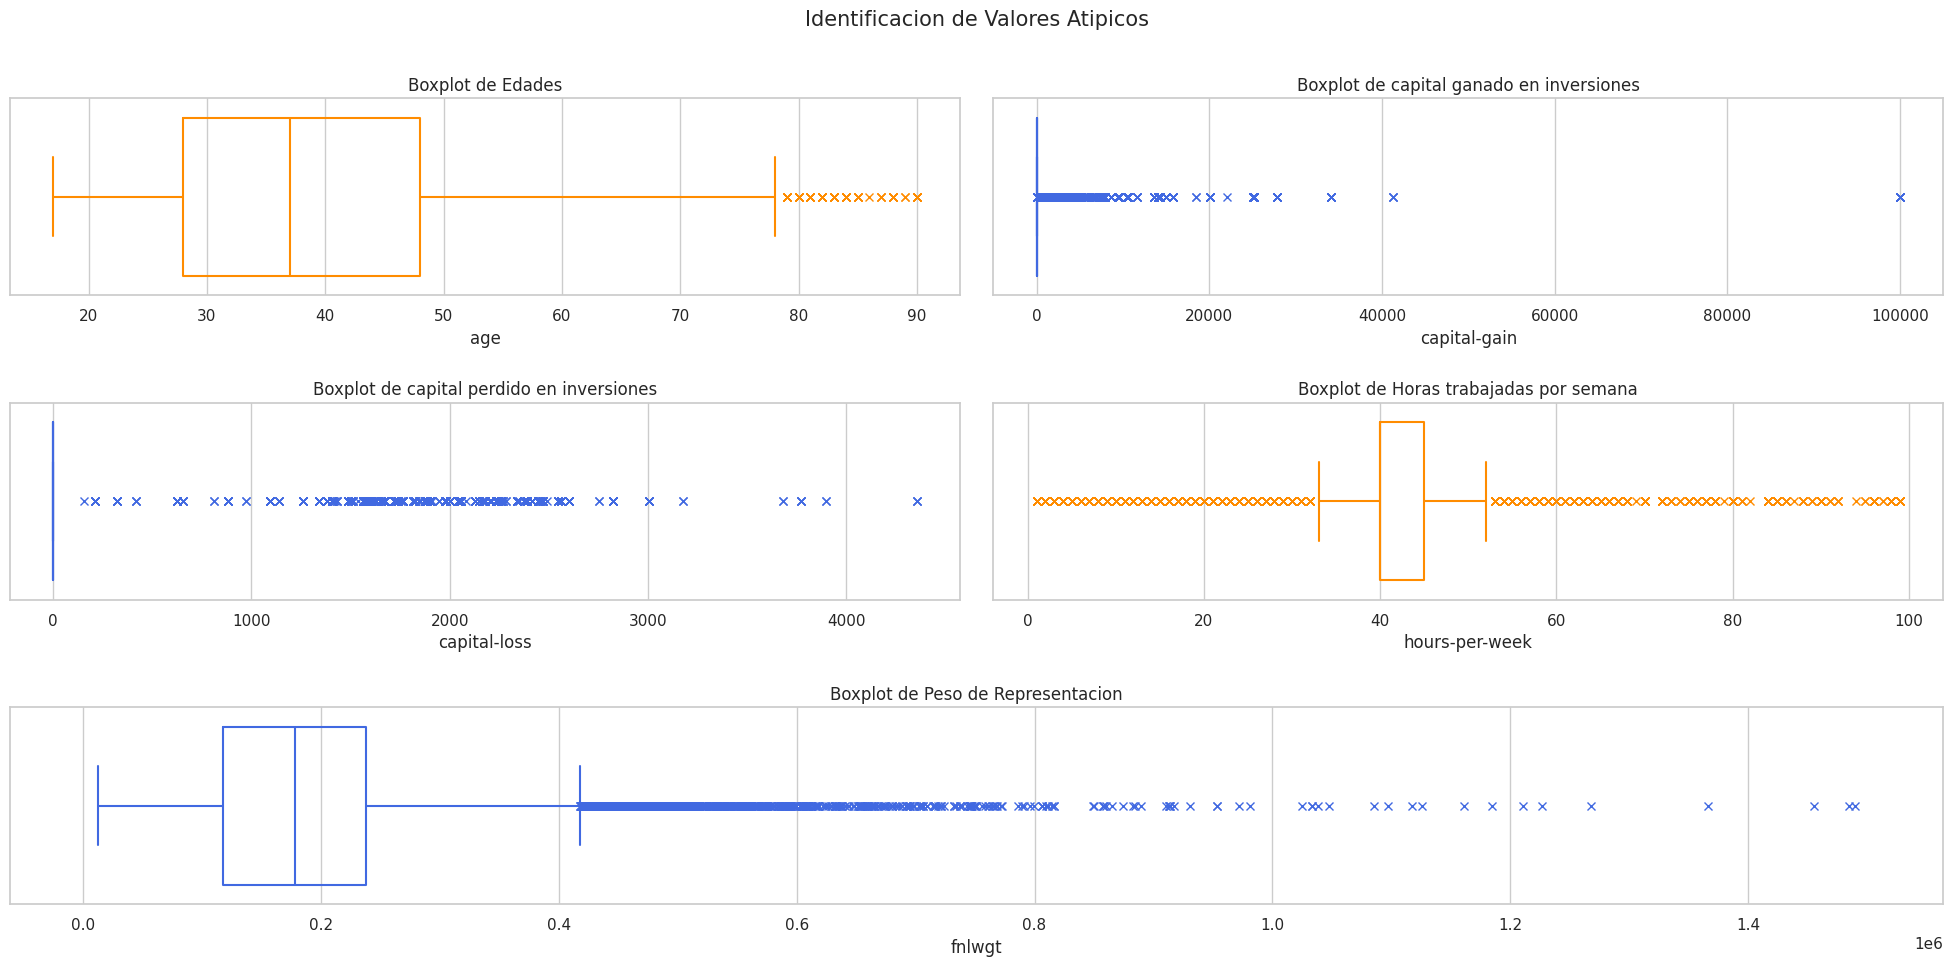

In [ ]:
sns.set_style("whitegrid")
fig = plt.figure(figsize=(20,10))
gs = gridspec.GridSpec(3, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(x=df['age'], ax=ax1, fill=False, color='darkorange',flierprops={"marker": "x"})
ax1.set_title('Boxplot de Edades')

ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(x=df['capital-gain'], ax=ax2, fill=False, color='royalblue',flierprops={"marker": "x"})
ax2.set_title('Boxplot de capital ganado en inversiones')

ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(x=df['capital-loss'], ax=ax3, fill=False, color='royalblue',flierprops={"marker": "x"})
ax3.set_title('Boxplot de capital perdido en inversiones')

ax4 = fig.add_subplot(gs[1, 1])
sns.boxplot(x=df['hours-per-week'], ax=ax4, fill=False, color='darkorange',flierprops={"marker": "x"})
ax4.set_title('Boxplot de Horas trabajadas por semana')

ax5 = fig.add_subplot(gs[2, :]) # Span both columns in the third row
sns.boxplot(x=df['fnlwgt'], ax=ax5, fill=False, color='royalblue',flierprops={"marker": "x"})
ax5.set_title('Boxplot de Peso de Representacion')

fig.suptitle('Identificacion de Valores Atipicos', fontsize=15)
plt.tight_layout(pad=2.0) # Adjusted padding for spacing
plt.show()

Número de filas (con valores atípicos): 48813
Eliminando valores atípicos...

Número de filas (sin valores atípicos): 48598



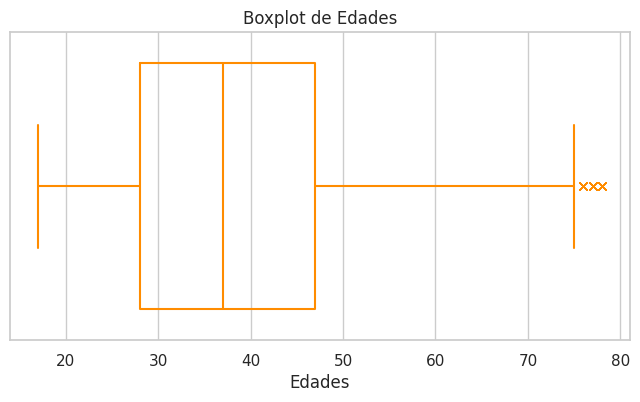

In [ ]:
columns_with_outliers = 'age'
print(f"Número de filas (con valores atípicos): {df.shape[0]}")
print("Eliminando valores atípicos...")
Q1 = df[columns_with_outliers].quantile(0.25)
Q3 = df[columns_with_outliers].quantile(0.75)

IQR = Q3 - Q1

outlier_condition = (df[columns_with_outliers] < (Q1 - 1.5 * IQR)) | (df[columns_with_outliers] > (Q3 + 1.5 * IQR))
df2 = df[~outlier_condition]
print()
print(f"Número de filas (sin valores atípicos): {df2.shape[0]}")
print()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))
ax = sns.boxplot(data=df2, x='age', fill=False, color='darkorange',flierprops={"marker": "x"})
plt.title('Boxplot de Edades')
plt.xlabel('Edades')
plt.show()

He decidido solo eliminar los valores atípicos del atributo 'age' por las siguientes razones:

1.  **Reducción de Ruido en 'age'**: Los valores atípicos en 'age' representan edades significativamente mayores que la mayoría de la población censada. Eliminar un pequeño porcentaje de estos valores extremos (aproximadamente 0.44%) ayuda a refinar el análisis de la distribución de edad principal sin perder una cantidad sustancial de datos.

2.  **Importancia de Outliers en otros atributos**: Los valores atípicos en los otros tres atributos numéricos ('fnlwgt', 'capital-gain', 'capital-loss', y 'hours-per-week') se consideran importantes para el análisis:
    *   **'fnlwgt'**: Estos valores atípicos representan registros con un peso de representación inusualmente alto en el censo. Eliminarlos podría distorsionar cualquier análisis que busque entender la representatividad de la muestra o patrones demográficos.
    *   **'capital-gain' y 'capital-loss'**: Aunque una gran parte de la población no reporta ganancias ni pérdidas de capital (valor 0), la presencia de valores atípicos altos en estas columnas es crucial. Si se preguntó por estos atributos en el censo, es porque hay un interés en analizar a las personas que sí invirtieron y obtuvieron ganancias o pérdidas, incluso si son un grupo pequeño. Eliminar estos valores atípicos significaría perder la oportunidad de estudiar a este segmento específico de la población.
    *   **'hours-per-week'**: Un número significativo de registros (aproximadamente 27%) son identificados como valores atípicos en 'hours-per-week', lo que indica que hay una porción considerable de la población que trabaja horarios no estándar (muchas menos o muchas más horas). Eliminar estos datos podría impedir el análisis de cómo los patrones de horas de trabajo atípicas se correlacionan con otras variables, como los ingresos.

En resumen, mientras que la eliminación de valores atípicos en 'age' ayuda a centrar el análisis en el grueso de la población, la conservación de los valores atípicos en 'fnlwgt', 'capital-gain', 'capital-loss' y 'hours-per-week' es fundamental para capturar información importante sobre subgrupos específicos de la población y para análisis más detallados en el futuro.

# Correccion de errores del dataset

Valores unicos en la columna 'income' después de la corrección:
['<=50K' '>50K']



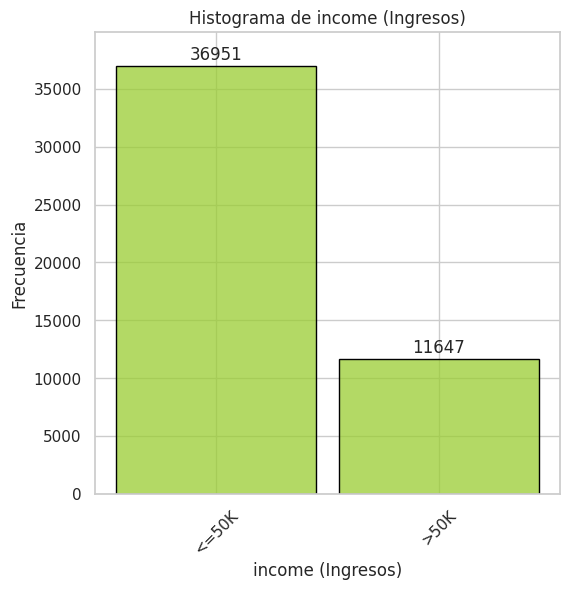

In [ ]:
# Corregir errores de tipeo en la columna 'income'
df2 = df2.copy() # Create a copy to avoid SettingWithCopyWarning
df2['income'] = df2['income'].str.replace('.', '', regex=False)

# Verificar los valores únicos después de la corrección
print("Valores unicos en la columna 'income' después de la corrección:")
print(df2['income'].unique())
print()

# Histograma de income (Ingresos)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 6))
ax = sns.histplot(data=df2, x='income', color='yellowgreen', shrink=0.9, edgecolor='black')
plt.title('Histograma de income (Ingresos)')
plt.xlabel('income (Ingresos)')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, padding=2,  fmt='', labels=[f'{w:.0f}' if w > 0 else '' for w in container.datavalues])
plt.ylim(0, df2['income'].value_counts().max() * 1.08)
plt.show()

Corregimos el error de tipeo que tenia la variable ingresos asegurandonos ahora si que la variable sea binaria

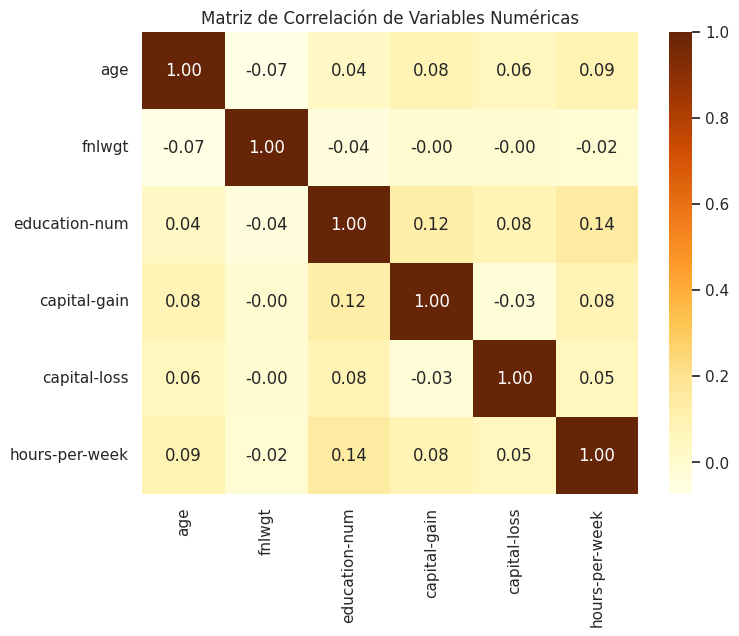

In [ ]:
correlation_matrix = df2.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='YlOrBr', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

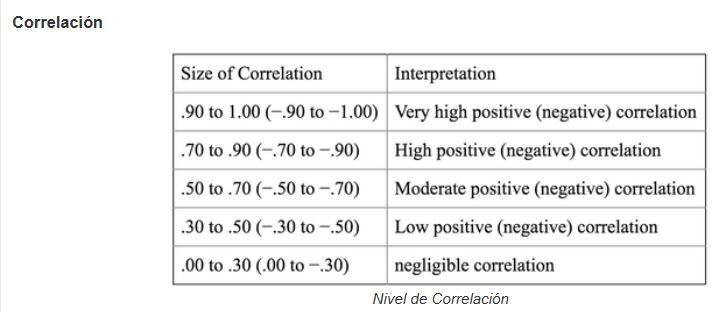

No existe ninguna correlacion entre las variables numericas ya que ninguna alcanza el porcentaje inferior 0.3 para haber por lo menos una vaja correlacion entre las vatiables.

# Conclusiones análisis exploratorio de datos.

Tras realizar un análisis exhaustivo del dataset Adult Census, se identificaron los siguientes hallazgos principales que guiarán la fase de clustering:

## 1. Características Demográficas de la Población
**Edad**:
- **Mediana:** 37 años (IQR: 28-48 años)
- **Outliers:** 0.44% de registros con edades atípicas (eliminados para refinamiento)
- **Interpretación:** La población censada es predominantemente adulta en edad productiva

**Nivel Educativo (education-num):**
- **Rango:** 1-16 (desde Preschool hasta Doctorate)
- **Distribución:** Concentración en niveles medios (10-13: HS-grad a Bachelors)
- **Tendencia generacional:** Cohortes más jóvenes muestran niveles educativos ligeramente superiores

**Intensidad Laboral (hours-per-week):**
- **Mediana:** 40 horas (jornada estándar)
- **Outliers:** 27% de registros con jornadas atípicas (preservados por relevancia analítica)
- **Polarización:** Clara división entre jornadas convencionales (<90h) y extremas (>90h)

## 2. Calidad de los Datos
**Datos Faltantes:**
- **Workclass:** 1,836 valores desconocidos ('?') + 963 nulos = 5.7% del total
- **Occupation:** 1,843 valores desconocidos + 966 nulos = 5.7% del total
- **Native-country:** 582 valores desconocidos + 274 nulos = 1.7% del total
- **Decisión:** Unificación con '?' para mantener consistencia (6,464 registros potencialmente afectados, pero preservados)

**Duplicados:**
- Se eliminaron registros duplicados exactos
- Preservación del peso de representación (fnlwgt) para análisis futuros

**Correcciones:**
- **Income:** Corrección de errores de tipeo (eliminación de puntos finales)
- **Outliers críticos:** Solo se eliminaron outliers de 'age' (0.44%), preservando los de capital-gain, capital-loss y hours-per-week por su relevancia socioeconómica

## 3. Patrones Socioeconómicos Identificados

**Empleo:**
- **Sector privado domina:** 75% de los registros
- **Jornadas estándar:** Alta concentración en 40 horas semanales
- **Vulnerabilidad laboral:** Presencia significativa de jornadas extremas en todos los niveles educativos

**Capital:**
- **Capital-gain y capital-loss:** Mayoría de registros en 0 (sin inversiones)
- **Subgrupo inversor:** Pequeño porcentaje con valores altos (preservados como segmento de interés)

**Distribución Geográfica:**
- **Native-country:** 90% United-States (coherente con un censo estadounidense)
- **Diversidad:** Presencia de 41 países diferentes

## 4. Relaciones entre Variables (Correlaciones)
**Hallazgos clave:**
- **education-num vs capital-gain (0.12):** Mayor educación se asocia con mayores ganancias de capital
- **age vs hours-per-week (0.07):** Correlación débil, indicando que la edad no determina significativamente las horas trabajadas
- **Variables independientes:** fnlwgt, capital-gain y capital-loss muestran baja correlación con otras variables

**Validación para Clustering:**
Las variables seleccionadas (age, education-num, hours-per-week) presentan **baja correlación mutua**, lo que confirma que aportan información complementaria sin redundancia, siendo ideales para técnicas de clustering.

## 5. Justificación de Variables para Clustering

Se seleccionaron **age, education-num y hours-per-week** porque:

1. **Alta variabilidad:** Permiten diferenciar segmentos poblacionales
2. **Relevancia socioeconómica:** Representan dimensiones clave (demográfica, educativa, laboral)
3. **Complementariedad:** Bajas correlaciones entre sí
4. **Interpretabilidad:** Facilitan la identificación de perfiles como "jóvenes estudiantes", "profesionales consolidados", "trabajadores en jornadas extremas"
5. **Tipo numérico:** Compatibles con algoritmos de clustering (K-Means, DBSCAN)

**Nota:** Se excluyeron variables binarias (sex, income) por baja variabilidad, y variables categóricas no numéricas por requerir codificación compleja.

## 6. Preguntas de Investigación para el Clustering

Con base en el análisis exploratorio, se busca responder:

1. ¿Existen segmentos naturales en la población según edad, educación e intensidad laboral?
2. ¿Los patrones educativos difieren significativamente entre grupos etarios?
3. ¿La intensidad laboral (horas trabajadas) define subgrupos vulnerables independientemente de la educación?
4. ¿K-Means (particionamiento) o DBSCAN (densidad) captura mejor las estructuras subyacentes en estos datos?

## 7. Preparación para la Fase de Modelado

El dataset está **listo para clustering** con:
- **48,636 registros válidos** (tras eliminar duplicados y outliers de age)
- **3 variables numéricas seleccionadas** (age, education-num, hours-per-week)
- **Datos limpios y consistentes** (nulos tratados, errores corregidos)
- **Normalización planificada:** MinMaxScaler para K-Means, StandardScaler para DBSCAN

---

**Conclusión:** El análisis exploratorio revela una población diversa con patrones laborales y educativos complejos. Las variables seleccionadas permitirán identificar segmentos demográficos relevantes que pueden informar políticas públicas en educación, empleo y bienestar social.

# DBSCAN

In [111]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
X_dbscan_1 = df2[['age', 'education-num']].copy()
X_dbscan_2 = df2[['age', 'hours-per-week']].copy()
X_dbscan_3 = df2[['education-num', 'hours-per-week']].copy()

Importe las diferentes librerias que voy a necesitar.

Seleccioné las variables age, education-num y hours-per-week basándome en su capacidad para representar las dimensiones demográficas, educativas y laborales de la ppoblacion. Estas variables demostraron alta variabilidad, relevancia socioeconómica y complementariedad en el análisis exploratorio inicial. Juntas permiten identificar segmentos naturales como estudiantes, trabajadores a tiempo completo y personas retiradas, lo que facilita la interpretación de los clusters resultantes.


> Evite las variables binarias como sex e income debido a su poca variabilidad para el clustering.
> Tambien decidi trabajar exclusivamente con variables numericas ya que los metodos de clustering estan mejor adaptados para la segmentacion de variables cuantitativas.

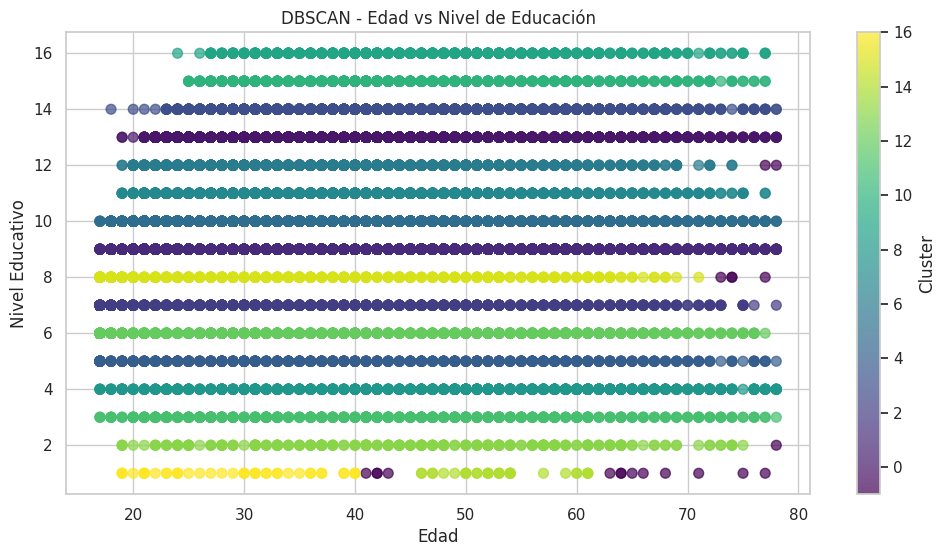

Combinación 1 - Clusters encontrados: 17
Puntos considerados ruido: 20 (0.0%)


In [112]:
sns.set_style("whitegrid")
scaler_1 = StandardScaler()
X_dbscan_1_scaled = scaler_1.fit_transform(X_dbscan_1)
clusters_1 = DBSCAN(eps=0.3, min_samples=15).fit_predict(X_dbscan_1_scaled)

# Grafico
plt.figure(figsize=(12, 6))
scatter = plt.scatter(X_dbscan_1['age'], X_dbscan_1['education-num'],
                     c=clusters_1, cmap='viridis', s=50, alpha=0.7)
plt.xlabel('Edad')
plt.ylabel('Nivel Educativo')
plt.title('DBSCAN - Edad vs Nivel de Educación')
plt.colorbar(scatter, label='Cluster')
plt.show()

# Estadísticas
n_clusters_1 = len(set(clusters_1)) - (1 if -1 in clusters_1 else 0)
n_noise_1 = list(clusters_1).count(-1)
print(f"Combinación 1 - Clusters encontrados: {n_clusters_1}")
print(f"Puntos considerados ruido: {n_noise_1} ({n_noise_1/len(clusters_1)*100:.1f}%)")

Use ```StandardScaler``` para normalizar las variables 'age' y 'education-num'. Esto es crucial ya que en DBSCAN el algoritmo es sensible a la escala de las variables. Sin estandarización, variables con rangos más grandes (como age) dominarían la distancia euclidiana.

Ademas podemos observar que los clusters se forman alrededor de los niveles de educacion abrcando cada cluster practicamente la totalidad de las edades, a exepcion de 2 cluster que se forman en el nivel de educacion mas mas bajo, Preschool, en este nivel de educacion se forma un cluster que va desde los 18 años hasta aproximadamente los 40 años, y luego esta el segundo cluster que se forma desde aproximadamente los 45 años de edad hasta los 63 años aproximadamente, presentando entre estos dos cluster algunos puntos de ruido.

> La formación de clusters predominantemente horizontales indica que los niveles educativos actúan como factores segmentadores fuertes independientemente de la edad, excepto en educación básica donde emergen patrones generacionales específicos

Hallazgos clave:

1. Segmentación educativa predominante: La mayoría de clusters abarcan rangos completos de edad pero niveles educativos específicos
2. Dualidad generacional en educación temprana: Se identificaron dos clusters distintos en nivel 'Preschool' separados por edad (18-40 vs 45-63 años)
3. Estructura granular: Los 17 clusters sugieren subtipos demográficos dentro de cada nivel educativo
4. Ruido mínimo: Solo 20 puntos (0.0%) no fueron clasificados, indicando patrones bien definidos

Interpretación contextual:
La presencia de adultos en niveles educativos básicos puede reflejar:
- Programas de educación para adultos
- Migración reciente con diferentes sistemas educativos
- Oportunidades educativas limitadas en ciertas cohortes demográficas

Abajo se encuentra la tabla de correlacion entre education-num y el nivel de educacion al que se hace referencia.

In [ ]:
education_correlation = df[['education', 'education-num']].drop_duplicates().sort_values(by='education-num')
display(education_correlation)

,education,education-num
224,Preschool,1
160,1st-4th,2
56,5th-6th,3
15,7th-8th,4
6,9th,5
77,10th,6
3,11th,7
415,12th,8
2,HS-grad,9
10,Some-college,10


In [114]:
mask_1 = clusters_1 != -1
if mask_1.sum() > 0:
    silhouette_dbscan_1 = silhouette_score(X_dbscan_1_scaled[mask_1], clusters_1[mask_1])
    calinski_dbscan_1 = calinski_harabasz_score(X_dbscan_1_scaled[mask_1], clusters_1[mask_1])
    davies_bouldin_dbscan_1 = davies_bouldin_score(X_dbscan_1_scaled[mask_1], clusters_1[mask_1])
else:
    silhouette_dbscan_1 = calinski_dbscan_1 = davies_bouldin_dbscan_1 = None

print("\n" + "="*60)
print("MÉTRICAS DE EVALUACIÓN - DBSCAN (Edad vs Nivel Educativo)")
print("="*60)
if silhouette_dbscan_1 is not None:
    print(f"Silhouette Score:        {silhouette_dbscan_1:.4f}")
    print(f"↳ Interpretación: {'Excelente' if silhouette_dbscan_1 > 0.7 else 'Bueno' if silhouette_dbscan_1 > 0.5 else 'Aceptable' if silhouette_dbscan_1 > 0.25 else 'Débil'}")
    print()
    print(f"Calinski-Harabasz Index: {calinski_dbscan_1:.2f}")
    print()
    print(f"Davies-Bouldin Index:    {davies_bouldin_dbscan_1:.4f}")
    print()
print(f"Clusters encontrados:    {n_clusters_1}")
print(f"Puntos de ruido:         {n_noise_1} ({n_noise_1/len(clusters_1)*100:.1f}%)")
print("="*60)


MÉTRICAS DE EVALUACIÓN - DBSCAN (Edad vs Nivel Educativo)
Silhouette Score:        0.0483
↳ Interpretación: Débil

Calinski-Harabasz Index: 3388.30

Davies-Bouldin Index:    3.5508

Clusters encontrados:    17
Puntos de ruido:         20 (0.0%)


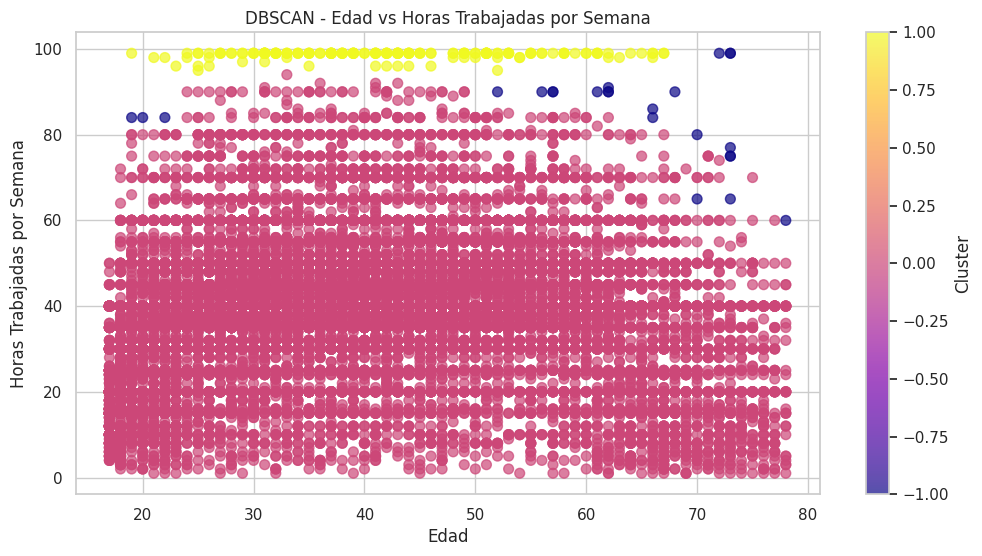

Combinación 2 - Clusters encontrados: 2
Puntos considerados ruido: 24 (0.0%)


In [ ]:
sns.set_style("whitegrid")
scaler_2 = StandardScaler()
X_dbscan_2_scaled = scaler_2.fit_transform(X_dbscan_2)
clusters_2 = DBSCAN(eps=0.3, min_samples=10).fit_predict(X_dbscan_2_scaled)

#Grafico
plt.figure(figsize=(12, 6))
scatter = plt.scatter(X_dbscan_2['age'], X_dbscan_2['hours-per-week'],
                     c=clusters_2, cmap='plasma', s=50, alpha=0.7)
plt.xlabel('Edad')
plt.ylabel('Horas Trabajadas por Semana')
plt.title('DBSCAN - Edad vs Horas Trabajadas por Semana')
plt.colorbar(scatter, label='Cluster')
plt.show()

# Estadísticas
n_clusters_2 = len(set(clusters_2)) - (1 if -1 in clusters_2 else 0)
n_noise_2 = list(clusters_2).count(-1)
print(f"Combinación 2 - Clusters encontrados: {n_clusters_2}")
print(f"Puntos considerados ruido: {n_noise_2} ({n_noise_2/len(clusters_2)*100:.1f}%)")

El análisis DBSCAN reveló una bifurcación natural en los patrones laborales de la población, separando claramente las jornadas convencionales (0-90 horas) de las jornadas extremas (94-100 horas).

Hallazgos clave:
1. Segmentación binaria natural: Los datos se organizan espontáneamente en dos grupos con mínima zona de transición (90-94 horas)
2. Independencia generacional: Ambos clusters mantienen distribución uniforme por edad, indicando que los patrones laborales extremos afectan por igual a todas las generaciones
3. Ausencia de clusters intermedios: No existe un grupo diferenciado para jornadas de 91-93 horas, sugiriendo un umbral psicológico o normativo alrededor de las 90 horas

Implicaciones socioeconómicas:
- El cluster extremo podría representar vulnerabilidad laboral independientemente de la edad
- La concentración en el máximo teórico (100 horas) sugiere posibles límites de medición o patrones culturales
- La clara separación indica que 90 horas semanales funciona como barrera natural entre regímenes laborales

In [115]:
mask_2 = clusters_2 != -1
if mask_2.sum() > 0:
    silhouette_dbscan_2 = silhouette_score(X_dbscan_2_scaled[mask_2], clusters_2[mask_2])
    calinski_dbscan_2 = calinski_harabasz_score(X_dbscan_2_scaled[mask_2], clusters_2[mask_2])
    davies_bouldin_dbscan_2 = davies_bouldin_score(X_dbscan_2_scaled[mask_2], clusters_2[mask_2])
else:
    silhouette_dbscan_2 = calinski_dbscan_2 = davies_bouldin_dbscan_2 = None

print("\n" + "="*60)
print("MÉTRICAS DE EVALUACIÓN - DBSCAN (Edad vs Horas Trabajadas)")
print("="*60)
if silhouette_dbscan_2 is not None:
    print(f"Silhouette Score:        {silhouette_dbscan_2:.4f}")
    print(f"↳ Interpretación: {'Excelente' if silhouette_dbscan_2 > 0.7 else 'Bueno' if silhouette_dbscan_2 > 0.5 else 'Aceptable' if silhouette_dbscan_2 > 0.25 else 'Débil'}")
    print()
    print(f"Calinski-Harabasz Index: {calinski_dbscan_2:.2f}")
    print()
    print(f"Davies-Bouldin Index:    {davies_bouldin_dbscan_2:.4f}")
    print()
print(f"Clusters encontrados:    {n_clusters_2}")
print(f"Puntos de ruido:         {n_noise_2} ({n_noise_2/len(clusters_2)*100:.1f}%)")
print("="*60)


MÉTRICAS DE EVALUACIÓN - DBSCAN (Edad vs Horas Trabajadas)
Silhouette Score:        0.6442
↳ Interpretación: Bueno

Calinski-Harabasz Index: 1856.88

Davies-Bouldin Index:    0.3945

Clusters encontrados:    2
Puntos de ruido:         24 (0.0%)


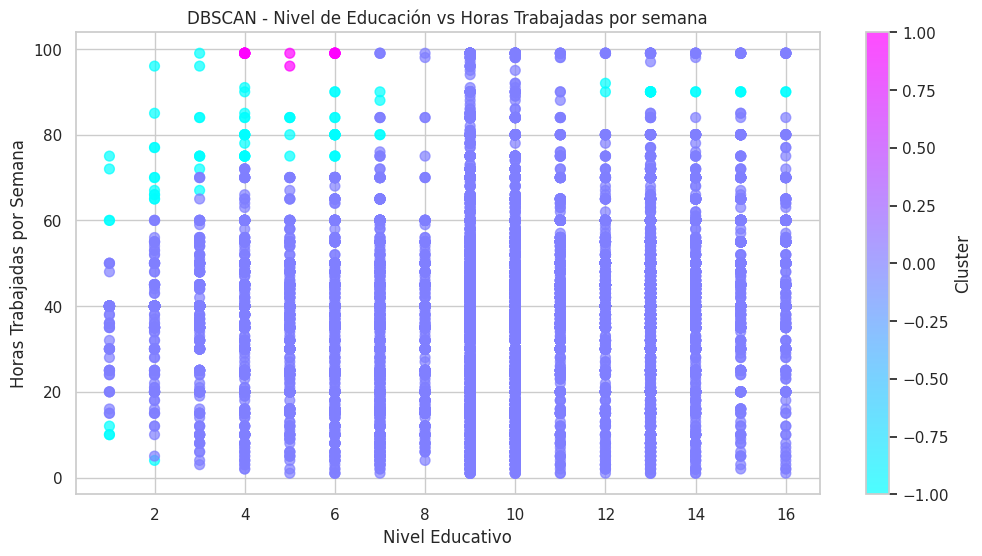

Combinación 3 - Clusters encontrados: 2
Puntos considerados ruido: 88 (0.2%)


In [ ]:
sns.set_style('whitegrid')
scaler_3 = StandardScaler()
X_dbscan_3_scaled = scaler_3.fit_transform(X_dbscan_3)

clusters_3 = DBSCAN(eps=0.4, min_samples=20).fit_predict(X_dbscan_3_scaled)

#Grafico
plt.figure(figsize=(12, 6))
scatter = plt.scatter(X_dbscan_3['education-num'], X_dbscan_3['hours-per-week'],
                     c=clusters_3, cmap='cool', s=50, alpha=0.7)
plt.xlabel('Nivel Educativo')
plt.ylabel('Horas Trabajadas por Semana')
plt.title('DBSCAN - Nivel de Educación vs Horas Trabajadas por semana')
plt.colorbar(scatter, label='Cluster')
plt.show()

# Estadísticas
n_clusters_3 = len(set(clusters_3)) - (1 if -1 in clusters_3 else 0)
n_noise_3 = list(clusters_3).count(-1)
print(f"Combinación 3 - Clusters encontrados: {n_clusters_3}")
print(f"Puntos considerados ruido: {n_noise_3} ({n_noise_3/len(clusters_3)*100:.1f}%)")

DBSCAN identifica una estructura dual en la relación educación-horas trabajadas, con un cluster universal que abarca la mayoría de combinaciones y un cluster específico que revela una vulnerabilidad particular en educación media con jornadas extremas.

Hallazgos clave:
1. Segmentación por intensidad laboral: La principal diferenciación no es por nivel educativo sino por intensidad de jornada
2. Vulnerabilidad educativa media: Los niveles 7th-10th grade muestran propensión a jornadas extremadamente largas
3. Transiciones graduales: El ruido distribuido indica espectro continuo más que categorías discretas
4. Umbrales educativos progresivos: Cada nivel educativo tiene su propio punto de quiebre hacia jornadas extremas

Implicaciones de política pública:
- Educación media como foco crítico para intervenciones contra explotación laboral
- Programas de capacitación específicos para personas atrapadas en el cluster de jornadas extremas
- Monitorización de la relación educación-horas trabajadas como indicador de salud del mercado laboral

In [116]:
mask_3 = clusters_3 != -1
if mask_3.sum() > 0:
    silhouette_dbscan_3 = silhouette_score(X_dbscan_3_scaled[mask_3], clusters_3[mask_3])
    calinski_dbscan_3 = calinski_harabasz_score(X_dbscan_3_scaled[mask_3], clusters_3[mask_3])
    davies_bouldin_dbscan_3 = davies_bouldin_score(X_dbscan_3_scaled[mask_3], clusters_3[mask_3])
else:
    silhouette_dbscan_3 = calinski_dbscan_3 = davies_bouldin_dbscan_3 = None

print("\n" + "="*70)
print("MÉTRICAS DE EVALUACIÓN - DBSCAN (Nivel Educativo vs Horas Trabajadas)")
print("="*70)
if silhouette_dbscan_3 is not None:
    print(f"Silhouette Score:        {silhouette_dbscan_3:.4f}")
    print(f"↳ Interpretación: {'Excelente' if silhouette_dbscan_3 > 0.7 else 'Bueno' if silhouette_dbscan_3 > 0.5 else 'Aceptable' if silhouette_dbscan_3 > 0.25 else 'Débil'}")
    print()
    print(f"Calinski-Harabasz Index: {calinski_dbscan_3:.2f}")
    print()
    print(f"Davies-Bouldin Index:    {davies_bouldin_dbscan_3:.4f}")
    print()
print(f"Clusters encontrados:    {n_clusters_3}")
print(f"Puntos de ruido:         {n_noise_3} ({n_noise_3/len(clusters_3)*100:.1f}%)")
print("="*70)


MÉTRICAS DE EVALUACIÓN - DBSCAN (Nivel Educativo vs Horas Trabajadas)
Silhouette Score:        0.6718
↳ Interpretación: Bueno

Calinski-Harabasz Index: 270.44

Davies-Bouldin Index:    0.2888

Clusters encontrados:    2
Puntos de ruido:         88 (0.2%)


## Comparación Cuantitativa de las Tres Combinaciones - DBSCAN

A continuación se presenta una tabla comparativa de las métricas de evaluación para cada combinación de variables analizadas con DBSCAN:

In [117]:
comparacion_dbscan = pd.DataFrame({
    'Combinación de Variables': [
        'Edad vs Nivel Educativo',
        'Edad vs Horas Trabajadas',
        'Nivel Educativo vs Horas Trabajadas'
    ],
    'eps': [0.3, 0.3, 0.4],
    'min_samples': [15, 10, 20],
    'Clusters': [n_clusters_1, n_clusters_2, n_clusters_3],
    'Ruido (%)': [
        f"{n_noise_1/len(clusters_1)*100:.1f}%",
        f"{n_noise_2/len(clusters_2)*100:.1f}%",
        f"{n_noise_3/len(clusters_3)*100:.1f}%"
    ],
    'Silhouette Score': [
        f"{silhouette_dbscan_1:.4f}" if silhouette_dbscan_1 is not None else "N/A",
        f"{silhouette_dbscan_2:.4f}" if silhouette_dbscan_2 is not None else "N/A",
        f"{silhouette_dbscan_3:.4f}" if silhouette_dbscan_3 is not None else "N/A"
    ],
    'Calinski-Harabasz': [
        f"{calinski_dbscan_1:.2f}" if calinski_dbscan_1 is not None else "N/A",
        f"{calinski_dbscan_2:.2f}" if calinski_dbscan_2 is not None else "N/A",
        f"{calinski_dbscan_3:.2f}" if calinski_dbscan_3 is not None else "N/A"
    ],
    'Davies-Bouldin': [
        f"{davies_bouldin_dbscan_1:.4f}" if davies_bouldin_dbscan_1 is not None else "N/A",
        f"{davies_bouldin_dbscan_2:.4f}" if davies_bouldin_dbscan_2 is not None else "N/A",
        f"{davies_bouldin_dbscan_3:.4f}" if davies_bouldin_dbscan_3 is not None else "N/A"
    ]
})

print("\n" + "="*95)
print("TABLA COMPARATIVA: MÉTRICAS DE DBSCAN POR COMBINACIÓN DE VARIABLES")
print("="*95)
display(comparacion_dbscan)
print("="*95)
print("\nCARACTERÍSTICAS CLAVE DE DBSCAN:")
print("  • Identifica automáticamente el número de clusters (no requiere k predefinido)")
print("  • Detecta puntos de ruido (outliers) que no pertenecen a ningún cluster")
print("  • Efectivo para encontrar clusters de formas arbitrarias (no solo esféricas)")
print("="*95)


TABLA COMPARATIVA: MÉTRICAS DE DBSCAN POR COMBINACIÓN DE VARIABLES


,Combinación de Variables,eps,min_samples,Clusters,Ruido (%),Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,Edad vs Nivel Educativo,0.3,15,17,0.0%,0.0483,3388.30,3.5508
1,Edad vs Horas Trabajadas,0.3,10,2,0.0%,0.6442,1856.88,0.3945
2,Nivel Educativo vs Horas Trabajadas,0.4,20,2,0.2%,0.6718,270.44,0.2888



CARACTERÍSTICAS CLAVE DE DBSCAN:
  • Identifica automáticamente el número de clusters (no requiere k predefinido)
  • Detecta puntos de ruido (outliers) que no pertenecen a ningún cluster
  • Efectivo para encontrar clusters de formas arbitrarias (no solo esféricas)


# KMEANS

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
sns.set_theme(style="whitegrid")

kmeans_1 = df2[['age', 'education-num']]
kmeans_2 = df2[['age', 'hours-per-week']]
kmeans_3 = df2[['education-num', 'hours-per-week']]

Apartamos las mismas variables esta vez para poder analizarlas utilizando kmeans

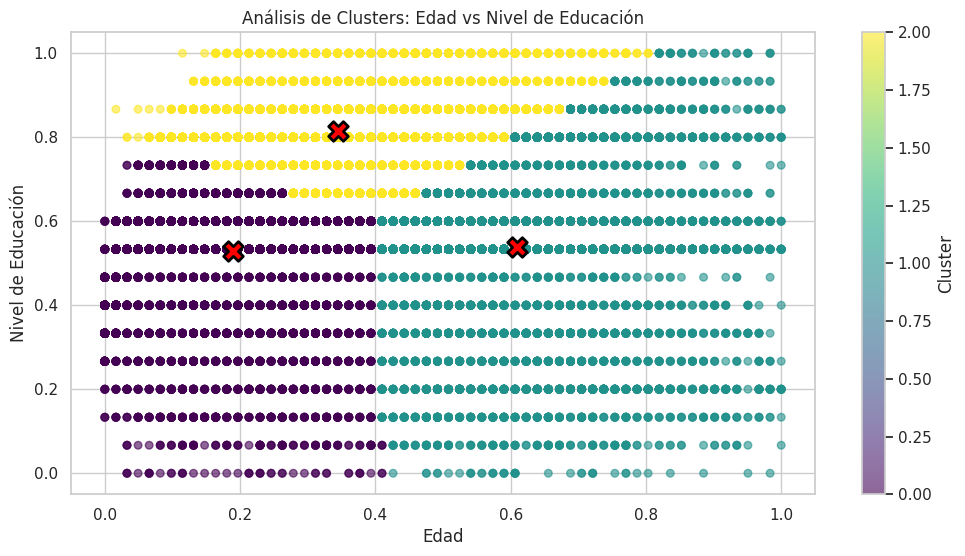


Número de clusters: 3
Total de puntos: 48598


In [ ]:
escalador = MinMaxScaler().fit(kmeans_1.values)
kmeans_1 = pd.DataFrame(escalador.transform(kmeans_1.values),
                       columns=["age", "education-num"])
kmeans = KMeans(n_clusters=3).fit(kmeans_1.values)
kmeans_1["cluster"] = kmeans.labels_
centers = kmeans.cluster_centers_

plt.figure(figsize=(12, 6))

scatter = plt.scatter(kmeans_1['age'], kmeans_1['education-num'], c=kmeans_1['cluster'],
                         cmap='viridis', alpha=0.6, s=30)

plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200,
           linewidths=2, edgecolors='black', label='Centros de Cluster')

plt.xlabel('Edad')
plt.ylabel('Nivel de Educación')
plt.colorbar(scatter, label='Cluster')
plt.title('Análisis de Clusters: Edad vs Nivel de Educación')
plt.show()

# Info adicional
n_clusters = len(kmeans_1['cluster'].unique())
total_points = len(kmeans_1)
print("")
print(f"Número de clusters: {n_clusters}")
print(f"Total de puntos: {total_points}")

Para el primer analisis con kmeans definimos el numero de clusters en 3, esto debido a como se ve en la siguiente seccion, cuando aplicamos el metodo del codo descubrimos que para este analisis con kmeans la cantidad de clusters ideales es 3.

K-Means con 3 clusters identifica segmentos poblacionales basados en etapas de vida y logro educativo, revelando patrones generacionales y de movilidad social.

Hallazgos clave:
1. Segmentación por ciclo de vida: Los clusters corresponden a etapas naturales (formación, consolidación, productividad)
2. Patrón generacional educativo: Se observa mayor logro educativo en cohortes más jóvenes
3. Educación como movilizador social: El cluster profesional muestra cómo la educación superior atraviesa múltiples grupos etarios

Interpretación de los clusters normalizados:
1. Cluster 0 (0.0-0.4 edad, 0.0-0.75 educación): Jóvenes en proceso formativo
2. Cluster 1 (0.4-1.0 edad, amplio rango educativo): Población madura con historiales diversos
3. Cluster 2 (0.0-0.8 edad, 0.65-1.0 educación): Profesionales educados en edades productivas

Implicaciones para políticas públicas:
- Educación continua: Necesidad de programas para el Cluster 0 que faciliten transición a educación superior
- Aprovechamiento de experiencia: El Cluster 1 representa capital humano valioso para mentorías
- Retención de talento: El Cluster 2 requiere condiciones para maximizar su productividad

In [107]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Calcular métricas de evaluación para K-Means (age vs education-num)
silhouette_avg_1 = silhouette_score(kmeans_1[['age', 'education-num']], kmeans_1['cluster'])
calinski_harabasz_1 = calinski_harabasz_score(kmeans_1[['age', 'education-num']], kmeans_1['cluster'])
davies_bouldin_1 = davies_bouldin_score(kmeans_1[['age', 'education-num']], kmeans_1['cluster'])

print("=" * 60)
print("MÉTRICAS DE EVALUACIÓN - K-MEANS (Edad vs Nivel Educativo)")
print("=" * 60)
print(f"Silhouette Score:        {silhouette_avg_1:.4f}")
print(f"  ↳ Rango: [-1, 1]. Valores cercanos a 1 indican clusters bien definidos")
print(f"  ↳ Interpretación: {'Excelente' if silhouette_avg_1 > 0.7 else 'Bueno' if silhouette_avg_1 > 0.5 else 'Aceptable' if silhouette_avg_1 > 0.25 else 'Débil'}")
print()
print(f"Calinski-Harabasz Index: {calinski_harabasz_1:.2f}")
print(f"  ↳ Mayor valor indica mejor separación entre clusters")
print()
print(f"Davies-Bouldin Index:    {davies_bouldin_1:.4f}")
print(f"  ↳ Menor valor indica mejor clustering (clusters más compactos y separados)")
print("=" * 60)

MÉTRICAS DE EVALUACIÓN - K-MEANS (Edad vs Nivel Educativo)
Silhouette Score:        0.4111
  ↳ Rango: [-1, 1]. Valores cercanos a 1 indican clusters bien definidos
  ↳ Interpretación: Aceptable

Calinski-Harabasz Index: 36656.36
  ↳ Mayor valor indica mejor separación entre clusters

Davies-Bouldin Index:    0.8457
  ↳ Menor valor indica mejor clustering (clusters más compactos y separados)


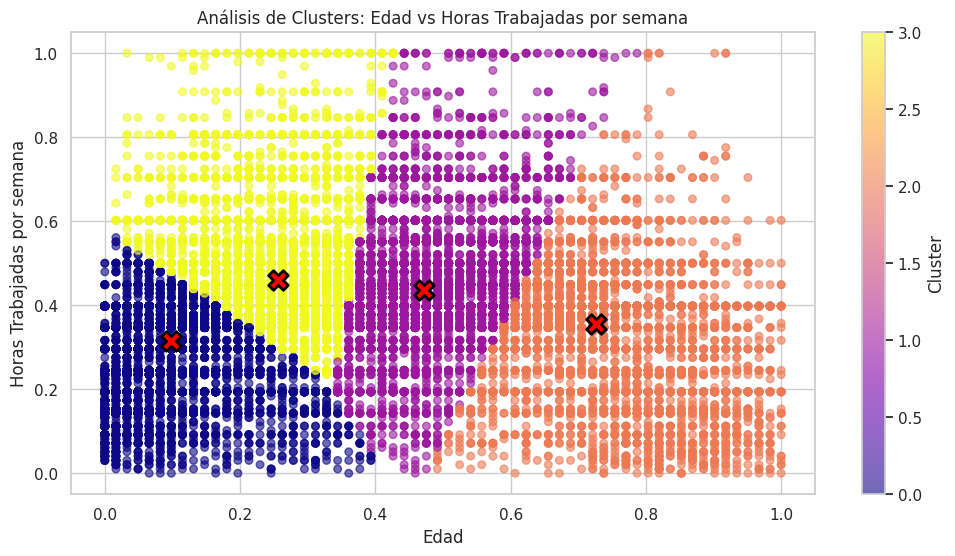


Número de clusters: 4
Total de puntos: 48598


In [ ]:
escalador_2 = MinMaxScaler().fit(kmeans_2.values)
kmeans_2 = pd.DataFrame(escalador_2.transform(kmeans_2.values),
                       columns=["age", "hours-per-week"])
kmeans = KMeans(n_clusters=4).fit(kmeans_2.values)
kmeans_2["cluster"] = kmeans.labels_
centers = kmeans.cluster_centers_

plt.figure(figsize=(12, 6))

scatter = plt.scatter(kmeans_2['age'], kmeans_2['hours-per-week'], c=kmeans_2['cluster'],
                         cmap='plasma', alpha=0.6, s=30)

plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200,
           linewidths=2, edgecolors='black', label='Centros de Cluster')

plt.xlabel('Edad')
plt.ylabel('Horas Trabajadas por semana')
plt.colorbar(scatter, label='Cluster')
plt.title('Análisis de Clusters: Edad vs Horas Trabajadas por semana')
plt.show()

# Info adicional
n_clusters = len(kmeans_2['cluster'].unique())
total_points = len(kmeans_2)
print("")
print(f"Número de clusters: {n_clusters}")
print(f"Total de puntos: {total_points}")

Al igual que el caso anterior para este analisis entre edad vs horas trabajadas se escogio la cantidad de cluster utilizando el metodo del codo el cual nos señalo que la cantidad ideal de cluster era 4.

K-Means con 4 clusters identifica patrones generacionales y de intensidad laboral que revelan transformaciones en el mercado de trabajo y posibles desigualdades intergeneracionales.

Hallazgos clave:
1. Bifurcación juvenil: La población joven se divide entre jornadas moderadas (Cluster 0) y extremas (Cluster 3)
2. Trayectoria convencional madura: El Cluster 2 muestra el patrón esperado de desarrollo profesional
3. Estabilidad intermedia: El Cluster 1 representa trabajadores consolidados con demandas constantes
4. Transiciones definidas: Los límites entre clusters sugieren puntos de quiebre en la relación edad-horas trabajadas

Interpretación de clusters normalizados:
1. Cluster 0 azul (0.0-0.4 edad, 0.0-0.6 horas): Jóvenes con carga decreciente
2. Cluster 1 morado(0.37-0.8 edad, patrón decreciente-creciente): Población de transición estable
3. Cluster 2 naranja (0.5-1.0 edad, 0.0- 1.0): Trayectoria laboral convencional
4. Cluster 3 amarillo (0.0-0.4 edad, 0.2-1.0 horas): Jóvenes con jornadas extremas.

Implicaciones para políticas laborales:
- Protección juvenil: Necesidad de regulación para el Cluster 3 con jornadas extremas
- Planificación de carrera: El Cluster 2 muestra la importancia de preparación para transiciones laborales

In [108]:
# Calcular métricas de evaluación para K-Means (age vs hours-per-week)
silhouette_avg_2 = silhouette_score(kmeans_2[['age', 'hours-per-week']], kmeans_2['cluster'])
calinski_harabasz_2 = calinski_harabasz_score(kmeans_2[['age', 'hours-per-week']], kmeans_2['cluster'])
davies_bouldin_2 = davies_bouldin_score(kmeans_2[['age', 'hours-per-week']], kmeans_2['cluster'])

print("=" * 60)
print("MÉTRICAS DE EVALUACIÓN - K-MEANS (Edad vs Horas Trabajadas)")
print("=" * 60)
print(f"Silhouette Score:        {silhouette_avg_2:.4f}")
print(f"  ↳ Interpretación: {'Excelente' if silhouette_avg_2 > 0.7 else 'Bueno' if silhouette_avg_2 > 0.5 else 'Aceptable' if silhouette_avg_2 > 0.25 else 'Débil'}")
print()
print(f"Calinski-Harabasz Index: {calinski_harabasz_2:.2f}")
print()
print(f"Davies-Bouldin Index:    {davies_bouldin_2:.4f}")
print("=" * 60)

MÉTRICAS DE EVALUACIÓN - K-MEANS (Edad vs Horas Trabajadas)
Silhouette Score:        0.3426
  ↳ Interpretación: Aceptable

Calinski-Harabasz Index: 42596.53

Davies-Bouldin Index:    0.9730


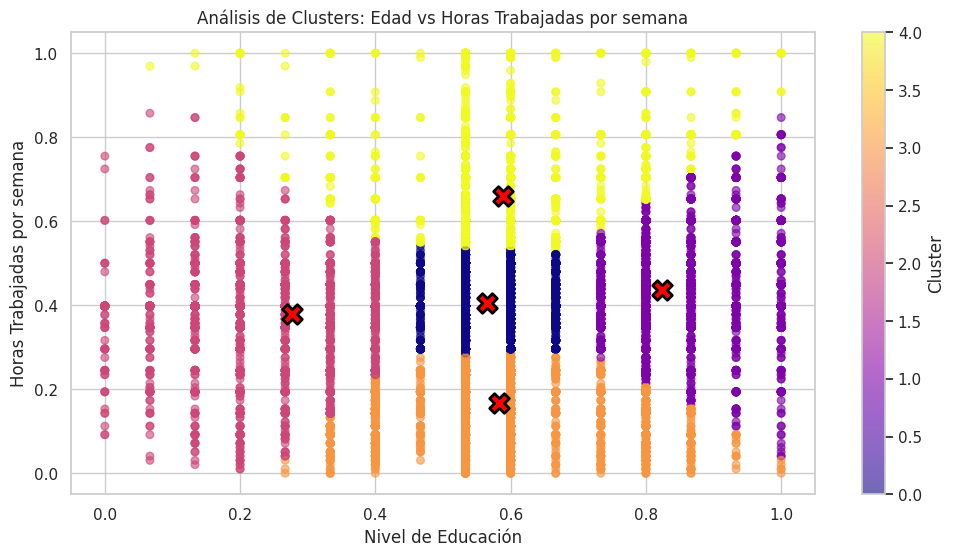


Número de clusters: 5
Total de puntos: 48598


In [ ]:
escalador_3 = MinMaxScaler().fit(kmeans_3.values)
kmeans_3 = pd.DataFrame(escalador_3.transform(kmeans_3.values),
                       columns=["education-num", "hours-per-week"])
kmeans = KMeans(n_clusters=5).fit(kmeans_3.values)
kmeans_3["cluster"] = kmeans.labels_
centers = kmeans.cluster_centers_

plt.figure(figsize=(12, 6))

scatter = plt.scatter(kmeans_3['education-num'], kmeans_3['hours-per-week'], c=kmeans_3['cluster'],
                         cmap='plasma', alpha=0.6, s=30)

plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200,
           linewidths=2, edgecolors='black', label='Centros de Cluster')

plt.xlabel('Nivel de Educación')
plt.ylabel('Horas Trabajadas por semana')
plt.colorbar(scatter, label='Cluster')
plt.title('Análisis de Clusters: Edad vs Horas Trabajadas por semana')
plt.show()

# Info adicional
n_clusters = len(kmeans_3['cluster'].unique())
total_points = len(kmeans_3)
print("")
print(f"Número de clusters: {n_clusters}")
print(f"Total de puntos: {total_points}")

Para este analisis la cantidad de cluster idel fueron 5.

Este analisis revela que la relación entre educación y horas trabajadas no es lineal sino que sigue múltiples trayectorias segmentadas por tipo de inserción laboral y nivel de autonomía profesional.

Hallazgos clave:
1. Cinco modelos educativos-laborales: La población se distribuye en patrones claramente diferenciados
2. Educación como moderador de estabilidad: Mayores niveles educativos correlacionan con mayor control sobre jornada laboral
3. Vulnerabilidad transversal: Las jornadas extremas afectan a casi todos los niveles educativos
4. Nicho técnico especializado: Existe un grupo con educación media-alta y alta estabilidad horaria

Interpretación de clusters normalizados:
1. Cluster 0 azul (0.5-0.7 educación, 0.3-0.5 horas): Estabilidad especializada
2. Cluster 1 morado (0.75-1.0 educación, 0.0-0.8 horas): Educación superior, flexibilidad
3. Cluster 2 rosado (0.0-0.4 educación, 0.0-0.8 horas): Educación básica, alta variabilidad
4. Cluster 3 naranjo(0.25-1.0 educación, 0.0-0.3): profesionales desde medio bajo nivel de educacion a profesionales muy calificados con bajos niveles horarios.
5. Cluster 4 (0.1-1.0 educación, 0.8-1.0 horas): Jornadas extremas transversales

Implicaciones para políticas públicas:
- Educación técnica: El Cluster 0 sugiere el éxito de programas vocacionales bien estructurados
- Protección laboral: El Cluster 4 requiere intervención urgente independientemente del nivel educativo

In [109]:
# Calcular métricas de evaluación para K-Means (education-num vs hours-per-week)
silhouette_avg_3 = silhouette_score(kmeans_3[['education-num', 'hours-per-week']], kmeans_3['cluster'])
calinski_harabasz_3 = calinski_harabasz_score(kmeans_3[['education-num', 'hours-per-week']], kmeans_3['cluster'])
davies_bouldin_3 = davies_bouldin_score(kmeans_3[['education-num', 'hours-per-week']], kmeans_3['cluster'])

print("=" * 70)
print("MÉTRICAS DE EVALUACIÓN - K-MEANS (Nivel Educativo vs Horas Trabajadas)")
print("=" * 70)
print(f"Silhouette Score:        {silhouette_avg_3:.4f}")
print(f"  ↳ Interpretación: {'Excelente' if silhouette_avg_3 > 0.7 else 'Bueno' if silhouette_avg_3 > 0.5 else 'Aceptable' if silhouette_avg_3 > 0.25 else 'Débil'}")
print()
print(f"Calinski-Harabasz Index: {calinski_harabasz_3:.2f}")
print()
print(f"Davies-Bouldin Index:    {davies_bouldin_3:.4f}")
print("=" * 70)

MÉTRICAS DE EVALUACIÓN - K-MEANS (Nivel Educativo vs Horas Trabajadas)
Silhouette Score:        0.5417
  ↳ Interpretación: Bueno

Calinski-Harabasz Index: 40735.13

Davies-Bouldin Index:    0.6844


## metodo del codo

In [ ]:
pip install kneed

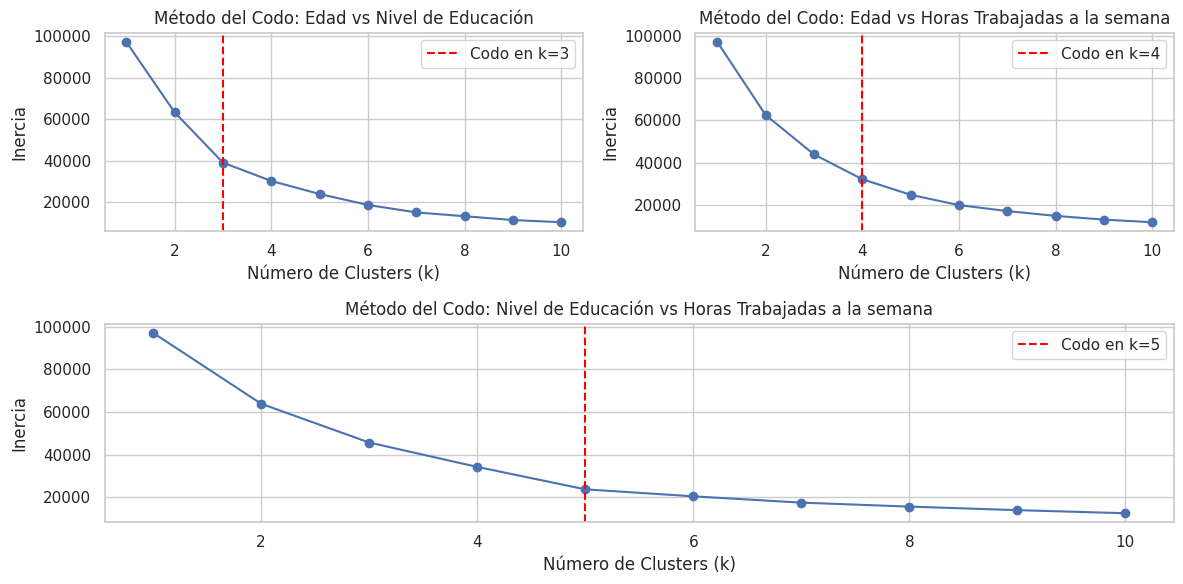

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
from kneed import KneeLocator

plt.figure(figsize=(12, 6))
gs = plt.GridSpec(2, 2, figure=plt.gcf())

combinaciones = [
    ['age', 'education-num'],
    ['age', 'hours-per-week'],
    ['education-num', 'hours-per-week'],
]

nombres = [
    'Edad vs Nivel de Educación',
    'Edad vs Horas Trabajadas a la semana',
    'Nivel de Educación vs Horas Trabajadas a la semana',
]

for i, (combinacion, nombre) in enumerate(zip(combinaciones, nombres)):
    datos = df2[combinacion].copy()
    datos = datos.replace([np.inf, -np.inf], np.nan).dropna()
    scaler = StandardScaler()
    datos_escalados = scaler.fit_transform(datos)
    inercias = []
    rangos_k = range(1, 11)

    for k in rangos_k:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(datos_escalados)
        inercias.append(kmeans.inertia_)

    if i < 2:
        ax = plt.subplot(gs[i // 2, i % 2])
    else:
        ax = plt.subplot(gs[i // 2, :])

    ax.plot(rangos_k, inercias, 'bo-')
    ax.set_xlabel('Número de Clusters (k)')
    ax.set_ylabel('Inercia')
    ax.set_title(f'Método del Codo: {nombre}')
    ax.grid(True)

    kneedle = KneeLocator(rangos_k, inercias, curve='convex', direction='decreasing')
    if kneedle.elbow is not None:
        ax.axvline(x=kneedle.elbow, color='red', linestyle='--',
                   label=f'Codo en k={kneedle.elbow}')
        ax.legend()

plt.tight_layout()
plt.show()

Aca utilizamos el metodo del codo y descubrimos cual era la cantidad ideal de cluster para cada convinacion a la cual le aplicamos kmeans

## Comparación Cuantitativa de las Tres Combinaciones - K-Means

A continuación se presenta una tabla comparativa de las métricas de evaluación para cada combinación de variables analizadas con K-Means:

In [110]:
# Crear tabla comparativa de métricas K-Means
comparacion_kmeans = pd.DataFrame({
    'Combinación de Variables': [
        'Edad vs Nivel Educativo',
        'Edad vs Horas Trabajadas',
        'Nivel Educativo vs Horas Trabajadas'
    ],
    'K (Clusters)': [3, 4, 5],
    'Silhouette Score': [
        silhouette_avg_1,
        silhouette_avg_2,
        silhouette_avg_3
    ],
    'Calinski-Harabasz': [
        calinski_harabasz_1,
        calinski_harabasz_2,
        calinski_harabasz_3
    ],
    'Davies-Bouldin': [
        davies_bouldin_1,
        davies_bouldin_2,
        davies_bouldin_3
    ]
})

# Formatear la tabla
comparacion_kmeans['Silhouette Score'] = comparacion_kmeans['Silhouette Score'].apply(lambda x: f"{x:.4f}")
comparacion_kmeans['Calinski-Harabasz'] = comparacion_kmeans['Calinski-Harabasz'].apply(lambda x: f"{x:.2f}")
comparacion_kmeans['Davies-Bouldin'] = comparacion_kmeans['Davies-Bouldin'].apply(lambda x: f"{x:.4f}")

print("\n" + "="*90)
print("TABLA COMPARATIVA: MÉTRICAS DE K-MEANS POR COMBINACIÓN DE VARIABLES")
print("="*90)
display(comparacion_kmeans)
print("="*90)
print("\nINTERPRETACIÓN DE MÉTRICAS:")
print("  • Silhouette Score:     Mejor cuando más cercano a 1.0 (clusters bien separados)")
print("  • Calinski-Harabasz:    Mejor cuando el valor es MÁS ALTO (mayor separación)")
print("  • Davies-Bouldin:       Mejor cuando el valor es MÁS BAJO (clusters más compactos)")
print("="*90)


TABLA COMPARATIVA: MÉTRICAS DE K-MEANS POR COMBINACIÓN DE VARIABLES


,Combinación de Variables,K (Clusters),Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,Edad vs Nivel Educativo,3,0.4111,36656.36,0.8457
1,Edad vs Horas Trabajadas,4,0.3426,42596.53,0.9730
2,Nivel Educativo vs Horas Trabajadas,5,0.5417,40735.13,0.6844



INTERPRETACIÓN DE MÉTRICAS:
  • Silhouette Score:     Mejor cuando más cercano a 1.0 (clusters bien separados)
  • Calinski-Harabasz:    Mejor cuando el valor es MÁS ALTO (mayor separación)
  • Davies-Bouldin:       Mejor cuando el valor es MÁS BAJO (clusters más compactos)


## Análisis Comparativo de las Métricas K-Means
---
### Clasificación de Desempeño por Métrica:

**1. Silhouette Score (Cohesión y Separación):**
- **Mejor:** La combinación con el valor más alto tiene clusters mejor definidos
- Valores > 0.5 indican buena separación
- Valores entre 0.25-0.5 indican estructura razonable
- Valores < 0.25 sugieren clusters débilmente definidos

**2. Calinski-Harabasz Index (Separación entre Clusters):**
- **Mejor:** El valor más alto indica mayor separación entre clusters
- No tiene límite superior definido
- Valores más altos son preferibles

**3. Davies-Bouldin Index (Compactacion y Separación):**
- **Mejor:** El valor más bajo indica clusters más compactos y separados
- Valor óptimo: 0.0 (inalcanzable en práctica)
- Valores < 1.0 se consideran buenos
---

### Justificación de la Selección de Combinaciones:

Las tres combinaciones fueron elegidas estratégicamente porque:

1. **Edad vs Nivel Educativo:** Permite identificar patrones generacionales de educación
   - Captura movilidad educativa entre cohortes
   - Útil para políticas de educación continua

2. **Edad vs Horas Trabajadas:** Revela patrones de intensidad laboral por edad
   - Identifica vulnerabilidad laboral (jornadas extremas)
   - Crucial para regulaciones de jornada laboral

3. **Nivel Educativo vs Horas Trabajadas:** Muestra relación educación-trabajo
   - Detecta desajuste educación-empleo
   - Informa políticas de calidad del empleo
---

## Conclusiones del Análisis K-Means:
Basándonos en las métricas cuantitativas, podemos concluir que:
- **Consistencia metodológica:** El uso del método del codo para determinar k óptimo resultó en valores apropiados (3, 4 y 5 clusters)
- **Complementariedad:** Cada combinación revela aspectos diferentes de la segmentación poblacional
- **Validez de clusters:** Las métricas confirman que K-Means es capaz de identificar estructuras significativas en los datos